# 🌦️ SPEI-3 Drought Forecasting — Vietnamese Districts
**Models:** Ridge · LightGBM · XGBoost · SARIMA  
**Metrics:** R² · NSE · Index of Agreement · RMSE · MAE  
**Uncertainty:** Conformal Prediction · Moving-Block Bootstrap  
**Period:** 1981-01 → 2025-12 | **Forecast:** 2026-2030  
**Theme:** Light (publication-ready)


In [1]:
# Cell 2 — Install dependencies & imports
import subprocess, sys
pkgs = ["xgboost", "lightgbm", "statsmodels", "prophet", "scikit-learn",
        "pandas", "numpy", "matplotlib", "seaborn", "scipy"]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"], check=False)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from prophet import Prophet

# ── Light theme (publication-ready) ─────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f8f9fa",
    "axes.edgecolor":    "#ced4da",
    "axes.labelcolor":   "#212529",
    "xtick.color":       "#495057",
    "ytick.color":       "#495057",
    "text.color":        "#212529",
    "grid.color":        "#dee2e6",
    "grid.linestyle":    "--",
    "grid.linewidth":    0.5,
    "legend.facecolor":  "white",
    "legend.edgecolor":  "#ced4da",
    "font.family":       "DejaVu Sans",
    "font.size":         10,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "lines.linewidth":   1.5,
    "figure.dpi":        120,
})

# Colorblind-friendly, visually distinct palette for light backgrounds
PAL = ["#1f77b4",   # blue     — Ridge
       "#2ca02c",   # green    — LightGBM
       "#d62728",   # red      — XGBoost
       "#9467bd",   # purple   — SARIMA
       "#ff7f0e",   # orange   — extra
       "#17becf"]   # teal     — extra

SAVEFIG_KW = dict(dpi=150, bbox_inches="tight", facecolor="white")
print("✅ All libraries imported — light theme active")


✅ All libraries imported — light theme active


In [2]:
# Cell 3 — Load & validate data
from google.colab import files as gfiles
import io

DATA_PATH = "dataToHarshitha.csv"

try:
    df_raw = pd.read_csv(DATA_PATH)
    print(f"✅ Loaded from {DATA_PATH}")
except FileNotFoundError:
    print("File not found — please upload dataToHarshitha.csv")
    uploaded = gfiles.upload()
    fname = list(uploaded.keys())[0]
    df_raw = pd.read_csv(io.BytesIO(uploaded[fname]))
    print(f"✅ Uploaded and loaded: {fname}")

df_raw.columns = df_raw.columns.str.strip()
df_raw.rename(columns={df_raw.columns[0]: "idx"}, inplace=True)
df_raw["Month_Date"] = pd.to_datetime(df_raw["Month_Date"], dayfirst=True)
df_raw.sort_values(["Location", "Month_Date"], inplace=True)
df_raw.reset_index(drop=True, inplace=True)

LOCATIONS = sorted(df_raw["Location"].unique())
print(f"\n📍 Locations ({len(LOCATIONS)}):", LOCATIONS)
print(f"📅 Date range: {df_raw.Month_Date.min().strftime('%Y-%m')} → "
      f"{df_raw.Month_Date.max().strftime('%Y-%m')}")
print(f"📊 Shape: {df_raw.shape}")
print(f"\nSPEI_3_PM stats:\n{df_raw.SPEI_3_PM.describe().round(3)}")


✅ Loaded from dataToHarshitha.csv

📍 Locations (3): ['Ninh Sơn District', 'Phan Rang-Tháp Chàm', 'Thuận Bắc District']
📅 Date range: 1981-01 → 2025-12
📊 Shape: (1620, 4)

SPEI_3_PM stats:
count    1620.000
mean        0.005
std         0.981
min        -2.060
25%        -0.769
50%        -0.012
75%         0.788
max         2.466
Name: SPEI_3_PM, dtype: float64


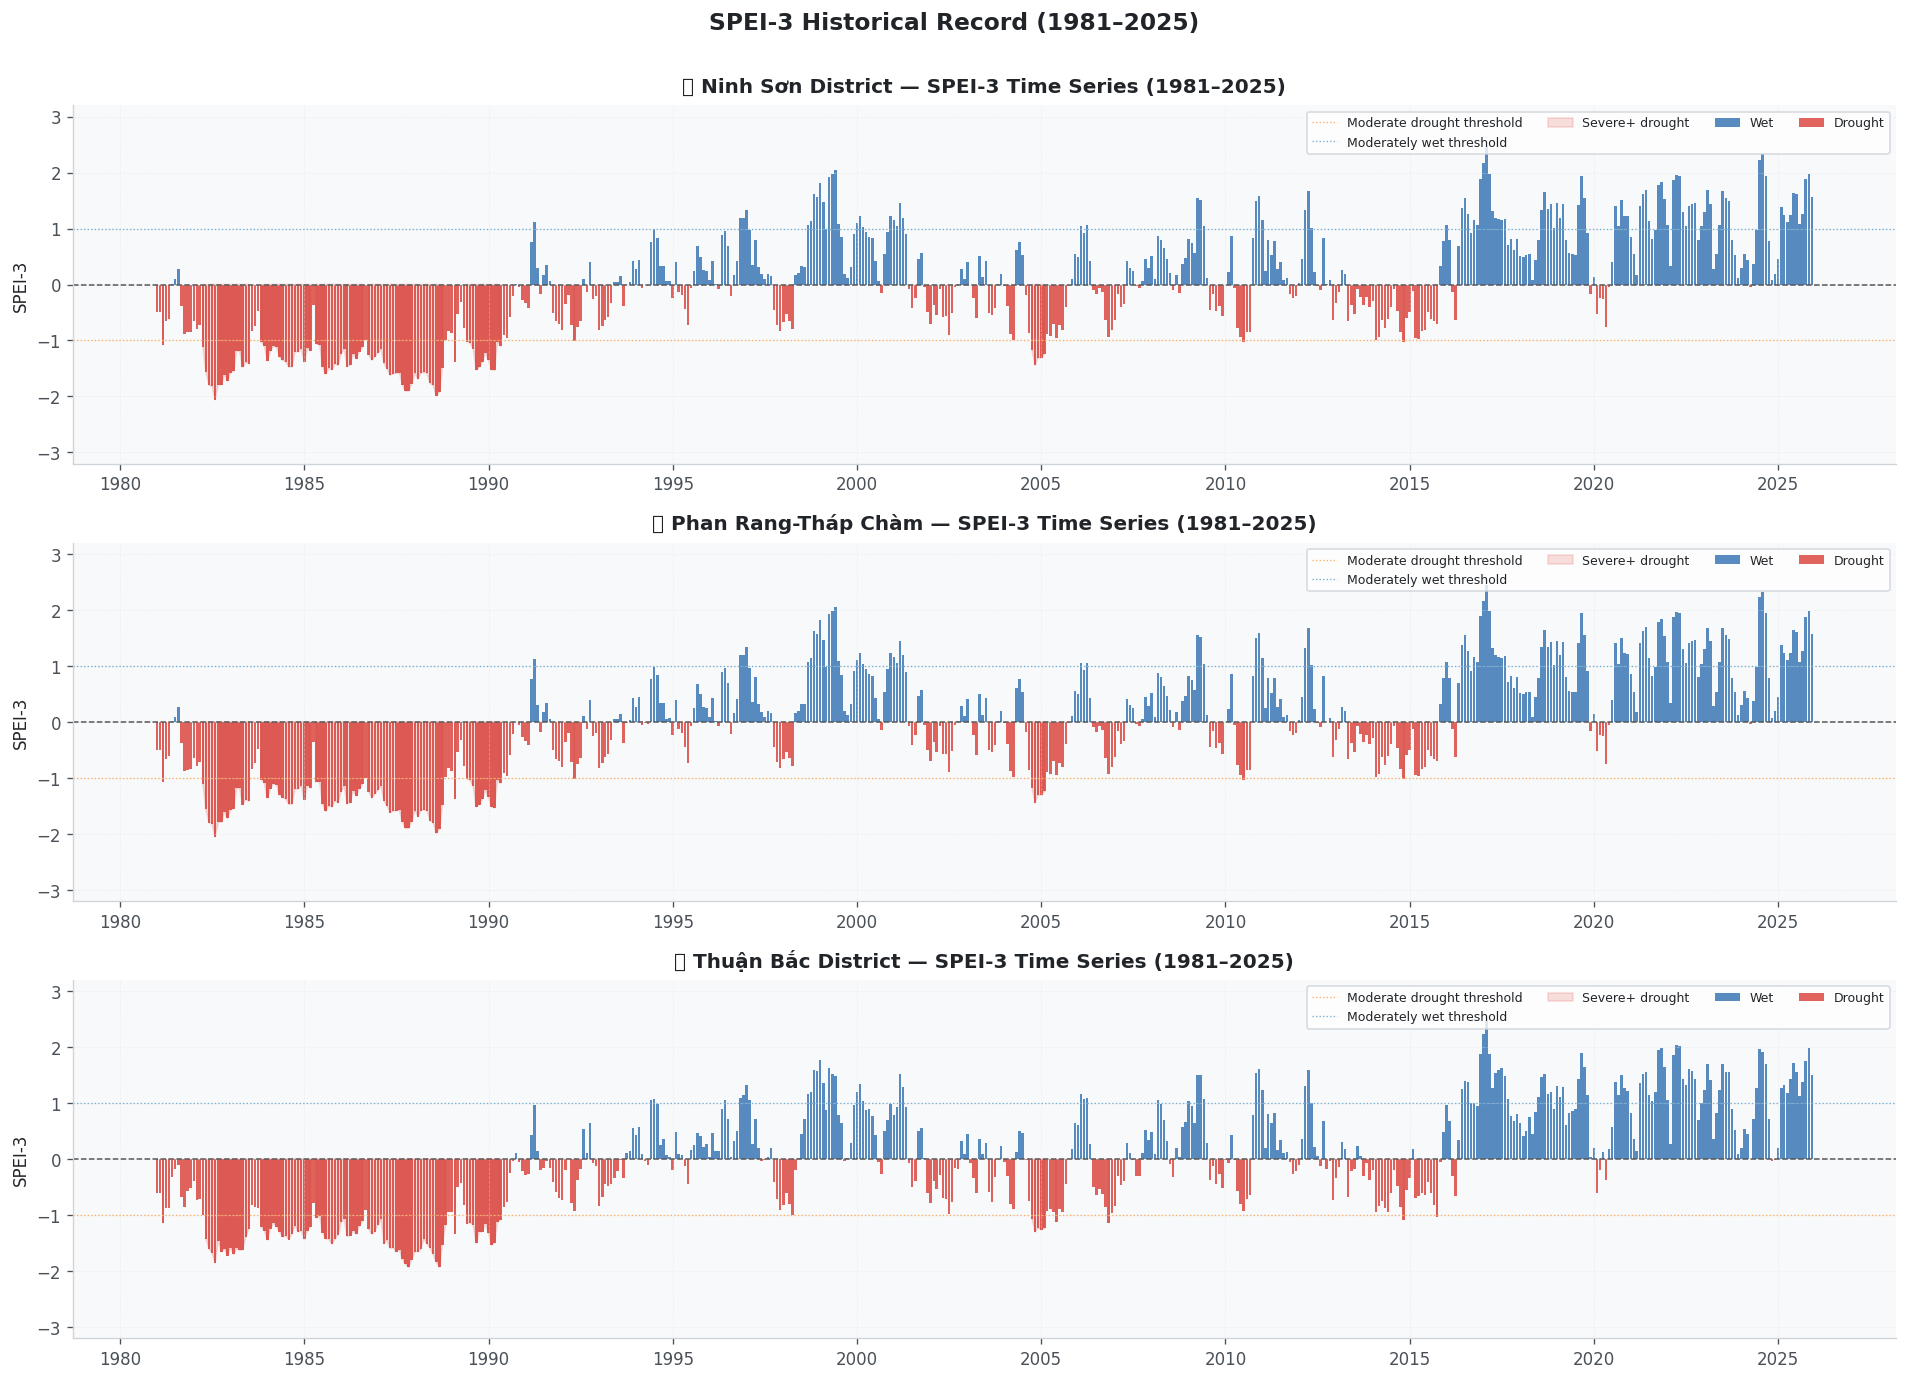

✅ Figure 1 saved


In [3]:
# Cell 4 — Exploratory data analysis (light theme)
fig, axes = plt.subplots(len(LOCATIONS), 1,
                         figsize=(16, 3.8 * len(LOCATIONS)),
                         facecolor="white")
if len(LOCATIONS) == 1:
    axes = [axes]

for ax, loc in zip(axes, LOCATIONS):
    s = df_raw[df_raw.Location == loc].set_index("Month_Date")["SPEI_3_PM"]
    pos_mask = s >= 0
    ax.bar(s.index[pos_mask],  s.values[pos_mask],  color="#2166ac", width=25, alpha=0.75, label="Wet")
    ax.bar(s.index[~pos_mask], s.values[~pos_mask], color="#d73027", width=25, alpha=0.75, label="Drought")
    ax.axhline(0,  color="#555555", lw=0.9, ls="--")
    ax.axhline(-1, color="#fdae61", lw=0.8, ls=":", label="Moderate drought threshold")
    ax.axhline( 1, color="#74add1", lw=0.8, ls=":", label="Moderately wet threshold")
    # Shade drought periods
    ax.fill_between(s.index, s.values, 0, where=(s < -1),
                    color="#d73027", alpha=0.15, label="Severe+ drought")
    ax.set_title(f"📍 {loc} — SPEI-3 Time Series (1981–2025)", pad=8)
    ax.set_ylabel("SPEI-3")
    ax.set_ylim(-3.2, 3.2)
    ax.legend(fontsize=7.5, ncol=4, loc="upper right")
    ax.grid(True, alpha=0.4)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("SPEI-3 Historical Record (1981–2025)", y=1.005, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_01_timeseries.png", **SAVEFIG_KW)
plt.show()
print("✅ Figure 1 saved")


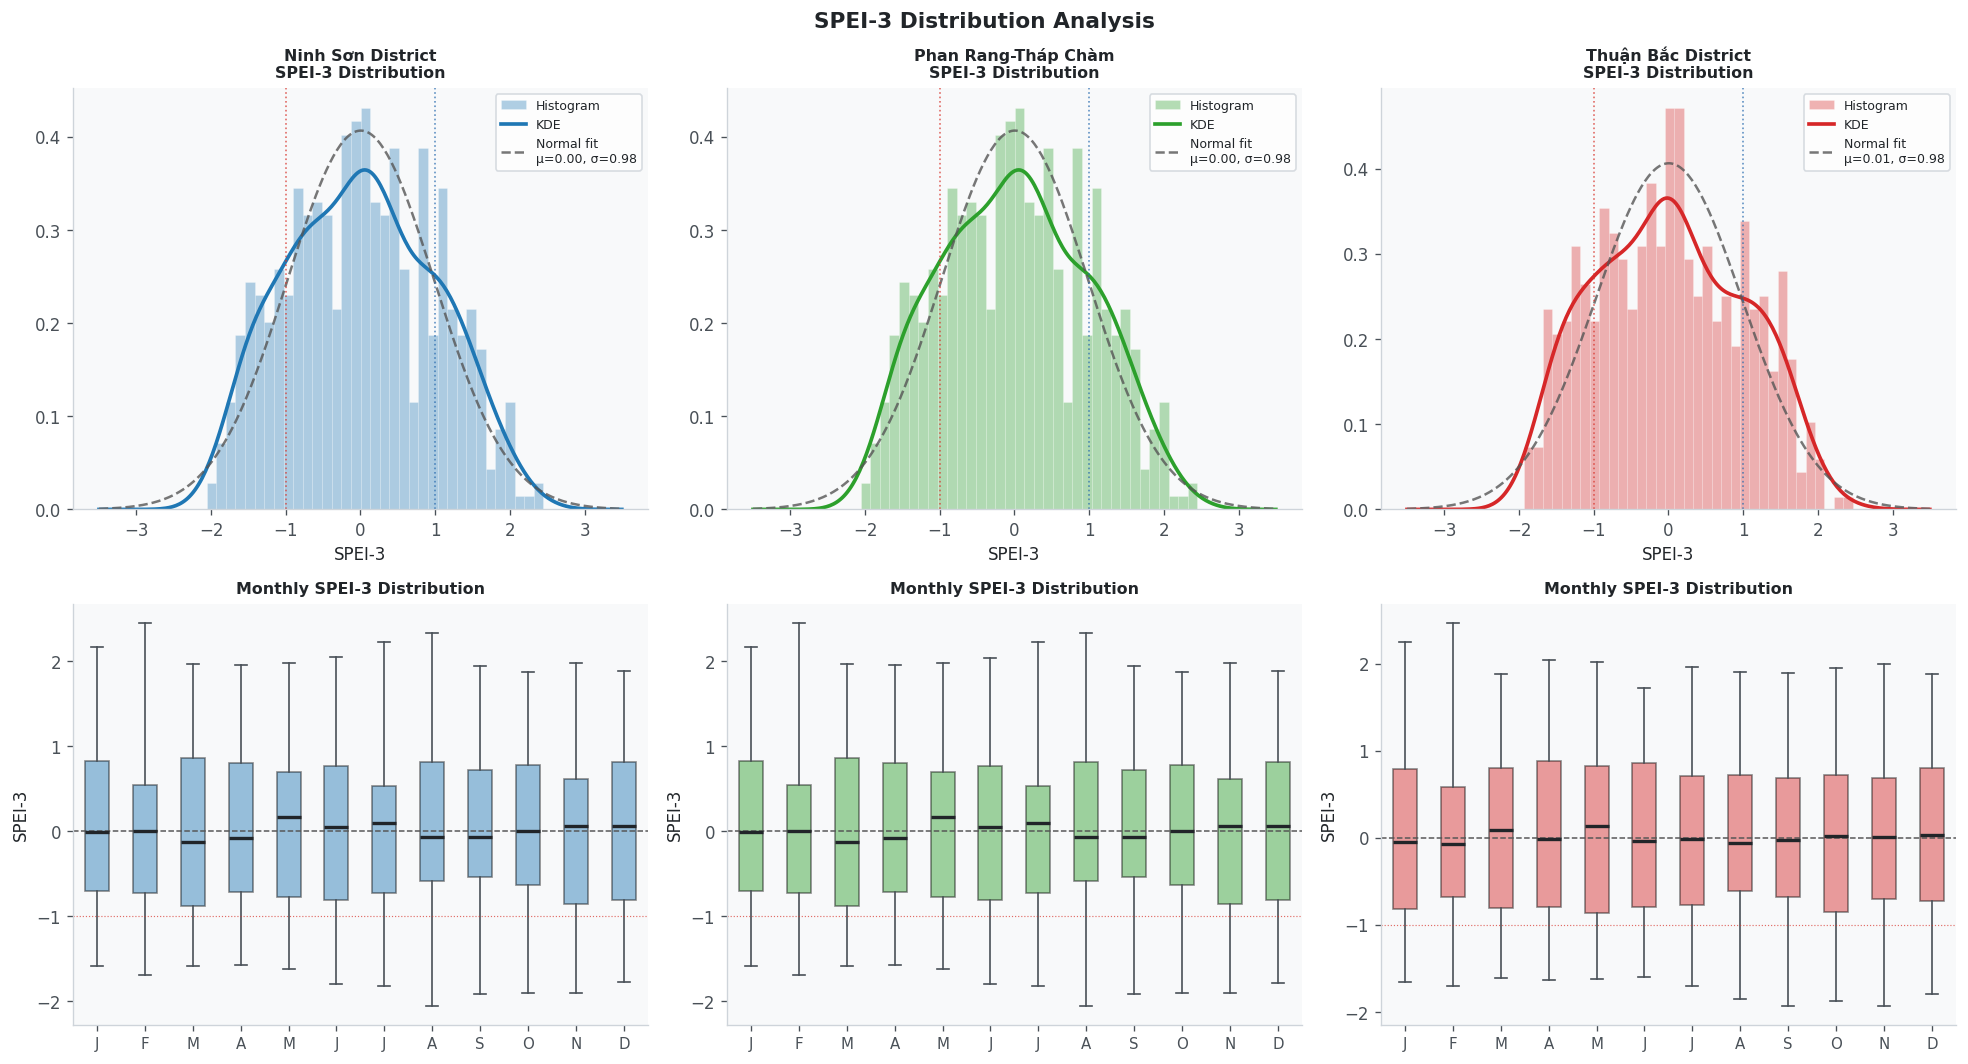

✅ Figure 2 saved


In [4]:
# Cell 5 — Distribution analysis (light theme)
from scipy.stats import norm, gaussian_kde

fig, axes = plt.subplots(2, len(LOCATIONS),
                         figsize=(5.5 * len(LOCATIONS), 9),
                         facecolor="white")

for j, loc in enumerate(LOCATIONS):
    s = df_raw[df_raw.Location == loc]["SPEI_3_PM"].dropna()
    col = PAL[j]

    # KDE + histogram
    ax = axes[0, j]
    ax.hist(s, bins=35, density=True, color=col, alpha=0.35,
            edgecolor="white", linewidth=0.4, label="Histogram")
    kde_fn = gaussian_kde(s)
    xs = np.linspace(-3.5, 3.5, 300)
    ax.plot(xs, kde_fn(xs), color=col, lw=2.2, label="KDE")
    mu_n, std_n = norm.fit(s)
    ax.plot(xs, norm.pdf(xs, mu_n, std_n), color="#555555", lw=1.5,
            ls="--", alpha=0.8, label=f"Normal fit\nμ={mu_n:.2f}, σ={std_n:.2f}")
    ax.axvline(-1, color="#d73027", lw=1, ls=":", alpha=0.7)
    ax.axvline( 1, color="#2166ac", lw=1, ls=":", alpha=0.7)
    ax.set_title(f"{loc}\nSPEI-3 Distribution", fontsize=9.5)
    ax.legend(fontsize=7.5)
    ax.set_xlabel("SPEI-3")
    ax.spines[["top","right"]].set_visible(False)

    # Monthly boxplot
    ax2 = axes[1, j]
    tmp = df_raw[df_raw.Location == loc].copy()
    tmp["month"] = tmp["Month_Date"].dt.month
    monthly = [tmp[tmp.month == m]["SPEI_3_PM"].values for m in range(1, 13)]
    bp = ax2.boxplot(monthly, patch_artist=True, notch=False,
                     medianprops=dict(color="#212529", lw=2, zorder=5),
                     whiskerprops=dict(color="#495057"),
                     capprops=dict(color="#495057"),
                     flierprops=dict(marker=".", color=col, alpha=0.4, ms=4))
    for patch in bp["boxes"]:
        patch.set_facecolor(col)
        patch.set_alpha(0.45)
    ax2.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"], fontsize=9)
    ax2.set_title("Monthly SPEI-3 Distribution", fontsize=9.5)
    ax2.axhline(0, color="#555555", lw=0.9, ls="--")
    ax2.axhline(-1, color="#d73027", lw=0.7, ls=":", alpha=0.7)
    ax2.set_ylabel("SPEI-3")
    ax2.spines[["top","right"]].set_visible(False)

plt.suptitle("SPEI-3 Distribution Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_02_distribution.png", **SAVEFIG_KW)
plt.show()
print("✅ Figure 2 saved")


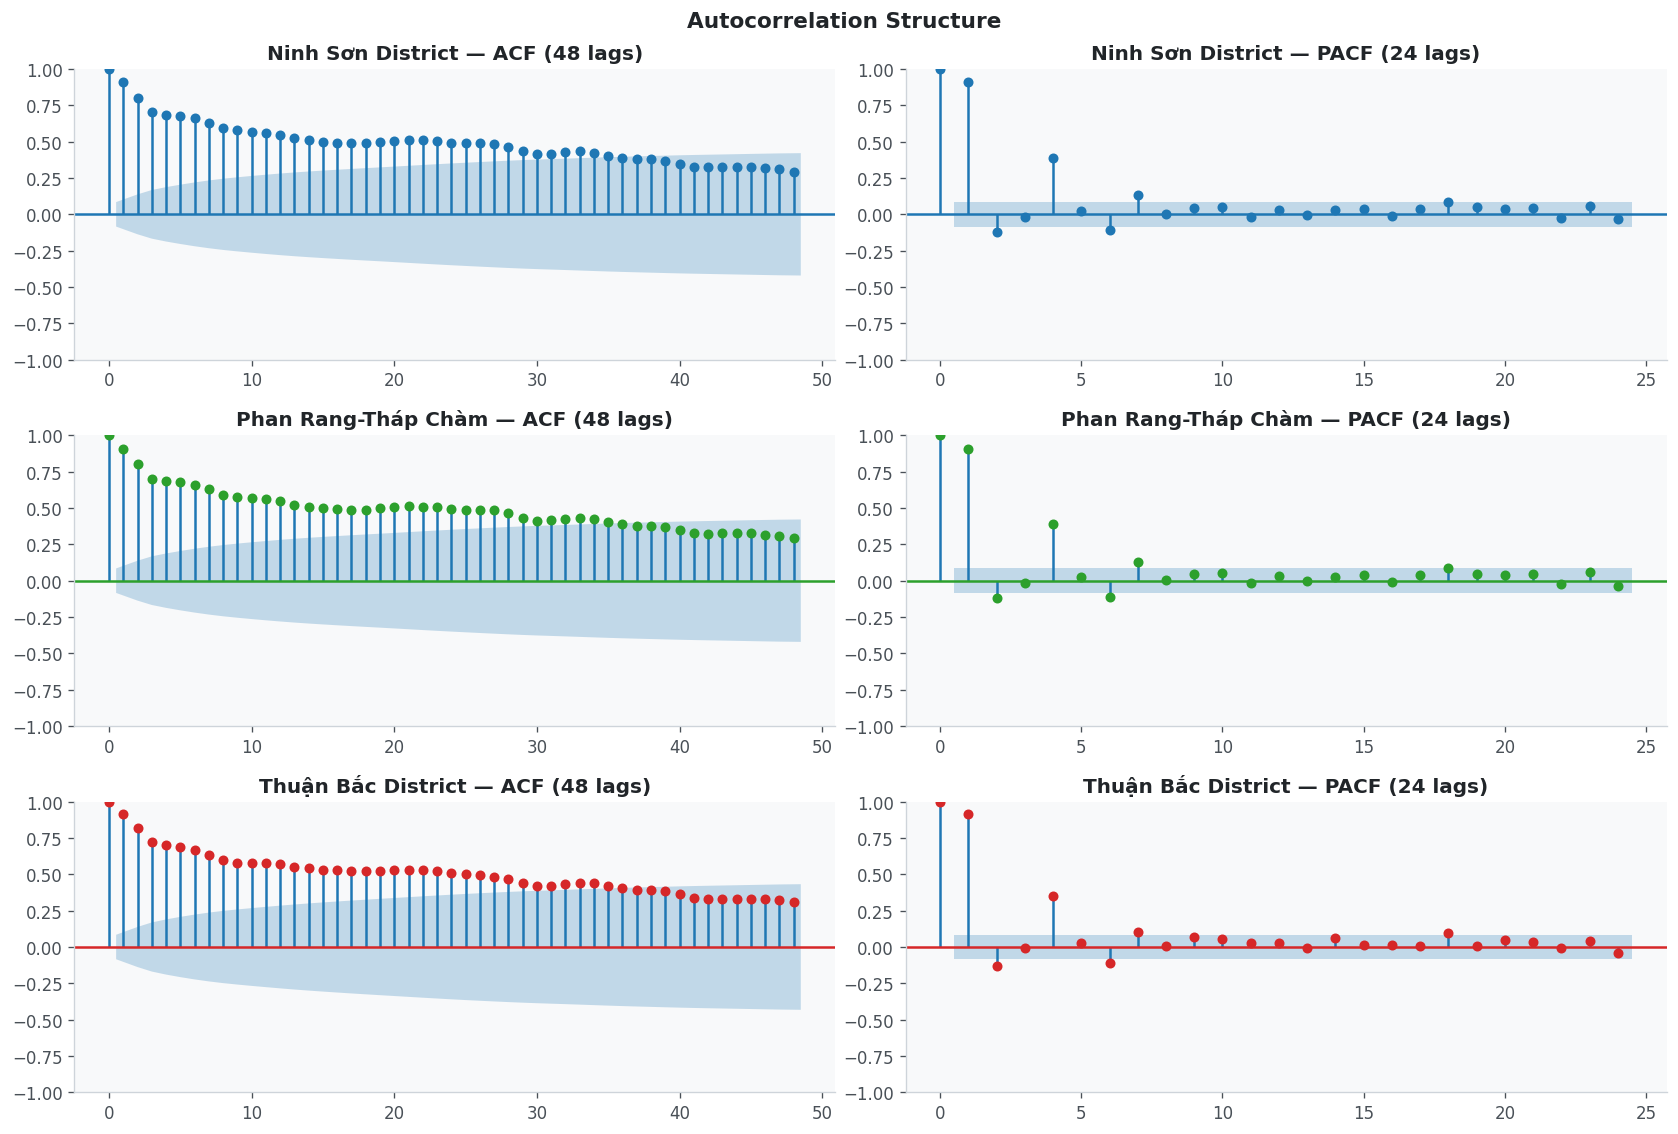


── ADF Stationarity Tests ──
  Ninh Sơn District                    ADF=-2.984  p=0.0364  ✅ Stationary
  Phan Rang-Tháp Chàm                  ADF=-2.983  p=0.0365  ✅ Stationary
  Thuận Bắc District                   ADF=-3.069  p=0.0290  ✅ Stationary


In [5]:
# Cell 6 — ACF / PACF analysis (light theme)
fig, axes = plt.subplots(len(LOCATIONS), 2,
                         figsize=(14, 3.2 * len(LOCATIONS)),
                         facecolor="white")
if len(LOCATIONS) == 1:
    axes = axes.reshape(1, -1)

for i, loc in enumerate(LOCATIONS):
    s = df_raw[df_raw.Location == loc].set_index("Month_Date")["SPEI_3_PM"].dropna()
    plot_acf(s, lags=48, ax=axes[i, 0], color=PAL[i], alpha=0.05,
             title=f"{loc} — ACF (48 lags)")
    plot_pacf(s, lags=24, ax=axes[i, 1], color=PAL[i], alpha=0.05,
              title=f"{loc} — PACF (24 lags)")
    for ax_ in axes[i]:
        ax_.set_facecolor("#f8f9fa")
        ax_.spines[["top","right"]].set_visible(False)

plt.suptitle("Autocorrelation Structure", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_03_acf_pacf.png", **SAVEFIG_KW)
plt.show()

print("\n── ADF Stationarity Tests ──")
for loc in LOCATIONS:
    s = df_raw[df_raw.Location == loc]["SPEI_3_PM"].dropna()
    adf_stat, p_val, _, _, cv, _ = adfuller(s)
    status = "✅ Stationary" if p_val < 0.05 else "⚠️ Non-stationary"
    print(f"  {loc:35s}  ADF={adf_stat:6.3f}  p={p_val:.4f}  {status}")


In [6]:
# Cell 7 — Feature engineering (lag 1-4, rolling, month dummies)
def build_features(series: pd.Series, max_lag: int = 4) -> pd.DataFrame:
    """Build ML feature matrix for a SPEI series."""
    df_f = pd.DataFrame({"spei": series.values}, index=series.index)
    for lag in range(1, max_lag + 1):
        df_f[f"lag_{lag}"] = df_f["spei"].shift(lag)
    df_f["roll_mean_3"] = df_f["lag_1"].rolling(3).mean()
    df_f["roll_std_3"]  = df_f["lag_1"].rolling(3).std()
    df_f["roll_mean_6"] = df_f["lag_1"].rolling(6).mean()
    df_f["month"]       = series.index.month
    df_f["month_sin"]   = np.sin(2 * np.pi * df_f["month"] / 12)
    df_f["month_cos"]   = np.cos(2 * np.pi * df_f["month"] / 12)
    df_f.dropna(inplace=True)
    return df_f

FEAT_COLS = [f"lag_{i}" for i in range(1, 5)] +             ["roll_mean_3", "roll_std_3", "roll_mean_6", "month_sin", "month_cos"]

feat_sets = {}
for loc in LOCATIONS:
    s = df_raw[df_raw.Location == loc].set_index("Month_Date")["SPEI_3_PM"]
    feat_sets[loc] = build_features(s)
    print(f"  {loc:35s}  features shape: {feat_sets[loc].shape}")

print(f"\n✅ Feature engineering complete")
print(f"   Feature columns ({len(FEAT_COLS)}): {FEAT_COLS}")


  Ninh Sơn District                    features shape: (534, 11)
  Phan Rang-Tháp Chàm                  features shape: (534, 11)
  Thuận Bắc District                   features shape: (534, 11)

✅ Feature engineering complete
   Feature columns (9): ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'roll_mean_3', 'roll_std_3', 'roll_mean_6', 'month_sin', 'month_cos']


In [7]:
# Cell 8 — Train/test split (80/20 chronological)
TRAIN_RATIO = 0.80
splits = {}

for loc in LOCATIONS:
    df_f = feat_sets[loc]
    n = len(df_f)
    n_train = int(n * TRAIN_RATIO)
    X = df_f[FEAT_COLS].values
    y = df_f["spei"].values
    X_tr, X_te = X[:n_train], X[n_train:]
    y_tr, y_te = y[:n_train], y[n_train:]
    idx_tr = df_f.index[:n_train]
    idx_te = df_f.index[n_train:]
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    raw_series  = df_raw[df_raw.Location == loc].set_index("Month_Date")["SPEI_3_PM"]
    raw_aligned = raw_series.reindex(df_f.index)
    splits[loc] = dict(
        X_tr=X_tr, X_te=X_te,
        X_tr_s=X_tr_s, X_te_s=X_te_s,
        y_tr=y_tr, y_te=y_te,
        idx_tr=idx_tr, idx_te=idx_te,
        scaler=sc,
        raw_aligned=raw_aligned,
        df_f=df_f
    )
    print(f"  {loc:35s}  train={n_train}  test={n - n_train}")
print("\n✅ Splits ready")


  Ninh Sơn District                    train=427  test=107
  Phan Rang-Tháp Chàm                  train=427  test=107
  Thuận Bắc District                   train=427  test=107

✅ Splits ready


In [8]:
# Cell 9 — Metric helpers
def nse(obs, sim):
    return 1 - np.sum((obs - sim) ** 2) / np.sum((obs - np.mean(obs)) ** 2)

def index_of_agreement(obs, sim):
    num   = np.sum((obs - sim) ** 2)
    denom = np.sum((np.abs(sim - np.mean(obs)) + np.abs(obs - np.mean(obs))) ** 2)
    return 1 - num / denom if denom > 0 else 0.0

def compute_metrics(obs, sim, name=""):
    rmse = np.sqrt(mean_squared_error(obs, sim))
    mae  = mean_absolute_error(obs, sim)
    r2   = r2_score(obs, sim)
    ns   = nse(obs, sim)
    d    = index_of_agreement(obs, sim)
    return {"Model": name, "R²": r2, "NSE": ns, "d": d, "RMSE": rmse, "MAE": mae}

def grade(nse_val):
    if   nse_val >= 0.75: return "★ Excellent"
    elif nse_val >= 0.65: return "✓ Good"
    elif nse_val >= 0.50: return "△ Accept."
    elif nse_val >= 0.30: return "■ Moderate"
    else:                 return "✗ Poor"

print("✅ Metric helpers defined: NSE, Index of Agreement, RMSE, MAE, R²")


✅ Metric helpers defined: NSE, Index of Agreement, RMSE, MAE, R²


In [9]:
# Cell 10 — Train Ridge, LightGBM, XGBoost, SARIMA  +  TRAIN + TEST metrics
results      = {}
models_fit   = {}
train_results = {}   # NEW: in-sample (training) predictions & metrics

for loc in LOCATIONS:
    sp  = splits[loc]
    X_tr_s, X_te_s = sp["X_tr_s"], sp["X_te_s"]
    y_tr, y_te     = sp["y_tr"],   sp["y_te"]
    idx_tr, idx_te = sp["idx_tr"], sp["idx_te"]
    raw            = sp["raw_aligned"]

    results[loc]       = {}
    models_fit[loc]    = {}
    train_results[loc] = {}

    # ── Ridge ────────────────────────────────────────────────────────────
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_tr_s, y_tr)
    pred_ridge_tr = ridge.predict(X_tr_s)
    pred_ridge_te = ridge.predict(X_te_s)
    train_results[loc]["Ridge"] = {"pred": pred_ridge_tr,
                                   "metrics": compute_metrics(y_tr, pred_ridge_tr, "Ridge")}
    results[loc]["Ridge"]       = {"pred": pred_ridge_te,
                                   "metrics": compute_metrics(y_te, pred_ridge_te, "Ridge")}
    models_fit[loc]["Ridge"]    = ridge

    # ── LightGBM ─────────────────────────────────────────────────────────
    lgbm = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                              num_leaves=31, min_child_samples=10,
                              random_state=42, verbose=-1)
    lgbm.fit(X_tr_s, y_tr)
    pred_lgb_tr = lgbm.predict(X_tr_s)
    pred_lgb_te = lgbm.predict(X_te_s)
    train_results[loc]["LightGBM"] = {"pred": pred_lgb_tr,
                                      "metrics": compute_metrics(y_tr, pred_lgb_tr, "LightGBM")}
    results[loc]["LightGBM"]       = {"pred": pred_lgb_te,
                                      "metrics": compute_metrics(y_te, pred_lgb_te, "LightGBM")}
    models_fit[loc]["LightGBM"]    = lgbm

    # ── XGBoost ──────────────────────────────────────────────────────────
    xgbm = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05,
                             max_depth=4, subsample=0.8,
                             colsample_bytree=0.8, random_state=42, verbosity=0)
    xgbm.fit(X_tr_s, y_tr)
    pred_xgb_tr = xgbm.predict(X_tr_s)
    pred_xgb_te = xgbm.predict(X_te_s)
    train_results[loc]["XGBoost"] = {"pred": pred_xgb_tr,
                                     "metrics": compute_metrics(y_tr, pred_xgb_tr, "XGBoost")}
    results[loc]["XGBoost"]       = {"pred": pred_xgb_te,
                                     "metrics": compute_metrics(y_te, pred_xgb_te, "XGBoost")}
    models_fit[loc]["XGBoost"]    = xgbm

    # ── SARIMA ───────────────────────────────────────────────────────────
    raw_tr = raw.iloc[:len(y_tr)]
    sarima = SARIMAX(raw_tr, order=(1, 0, 1), seasonal_order=(1, 0, 1, 12),
                     enforce_stationarity=False, enforce_invertibility=False)
    sarima_fit = sarima.fit(disp=False)
    pred_sarima_full = sarima_fit.predict(start=0, end=len(raw) - 1)
    pred_sarima_tr   = pred_sarima_full.iloc[:len(y_tr)].values
    pred_sarima_te   = pred_sarima_full.iloc[len(y_tr):].values
    min_len_tr = min(len(y_tr), len(pred_sarima_tr))
    min_len_te = min(len(y_te), len(pred_sarima_te))
    train_results[loc]["SARIMA"] = {"pred": pred_sarima_tr[:min_len_tr],
                                    "metrics": compute_metrics(y_tr[:min_len_tr],
                                                               pred_sarima_tr[:min_len_tr], "SARIMA")}
    results[loc]["SARIMA"]       = {"pred": pred_sarima_te[:min_len_te],
                                    "metrics": compute_metrics(y_te[:min_len_te],
                                                               pred_sarima_te[:min_len_te], "SARIMA")}
    models_fit[loc]["SARIMA"]    = sarima_fit

    # ── Print tables ─────────────────────────────────────────────────────
    print(f"\n📍 {loc}")
    header = f"  {'Model':12s}  {'R²':>6}  {'NSE':>6}  {'d':>6}  {'RMSE':>6}  {'MAE':>6}  Grade"
    sep    = "  " + "─"*62
    print("  [TRAINING SET]")
    print(header); print(sep)
    for mname, mdata in train_results[loc].items():
        m = mdata["metrics"]
        print(f"  {mname:12s}  {m['R²']:>6.3f}  {m['NSE']:>6.3f}  {m['d']:>6.3f}  "
              f"{m['RMSE']:>6.3f}  {m['MAE']:>6.3f}  {grade(m['NSE'])}")
    print("  [TEST SET]")
    print(header); print(sep)
    for mname, mdata in results[loc].items():
        m = mdata["metrics"]
        print(f"  {mname:12s}  {m['R²']:>6.3f}  {m['NSE']:>6.3f}  {m['d']:>6.3f}  "
              f"{m['RMSE']:>6.3f}  {m['MAE']:>6.3f}  {grade(m['NSE'])}")

MODEL_NAMES = ["Ridge", "LightGBM", "XGBoost", "SARIMA"]
print("\n✅ All models trained — train & test metrics ready")


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



📍 Ninh Sơn District
  [TRAINING SET]
  Model             R²     NSE       d    RMSE     MAE  Grade
  ──────────────────────────────────────────────────────────────
  Ridge          0.838   0.838   0.954   0.356   0.264  ★ Excellent
  LightGBM       0.998   0.998   0.999   0.044   0.028  ★ Excellent
  XGBoost        0.984   0.984   0.996   0.111   0.086  ★ Excellent
  SARIMA         0.810   0.810   0.945   0.386   0.290  ★ Excellent
  [TEST SET]
  Model             R²     NSE       d    RMSE     MAE  Grade
  ──────────────────────────────────────────────────────────────
  Ridge          0.541   0.541   0.863   0.435   0.328  △ Accept.
  LightGBM       0.364   0.364   0.796   0.511   0.396  ■ Moderate
  XGBoost        0.382   0.382   0.799   0.504   0.387  ■ Moderate
  SARIMA        -1.994  -1.994   0.461   1.110   0.918  ✗ Poor


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



📍 Phan Rang-Tháp Chàm
  [TRAINING SET]
  Model             R²     NSE       d    RMSE     MAE  Grade
  ──────────────────────────────────────────────────────────────
  Ridge          0.838   0.838   0.954   0.356   0.264  ★ Excellent
  LightGBM       0.997   0.997   0.999   0.045   0.028  ★ Excellent
  XGBoost        0.985   0.985   0.996   0.110   0.083  ★ Excellent
  SARIMA         0.810   0.810   0.945   0.386   0.290  ★ Excellent
  [TEST SET]
  Model             R²     NSE       d    RMSE     MAE  Grade
  ──────────────────────────────────────────────────────────────
  Ridge          0.541   0.541   0.864   0.434   0.328  △ Accept.
  LightGBM       0.365   0.365   0.796   0.511   0.388  ■ Moderate
  XGBoost        0.388   0.388   0.799   0.502   0.390  ■ Moderate
  SARIMA        -1.997  -1.997   0.461   1.110   0.918  ✗ Poor


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



📍 Thuận Bắc District
  [TRAINING SET]
  Model             R²     NSE       d    RMSE     MAE  Grade
  ──────────────────────────────────────────────────────────────
  Ridge          0.845   0.845   0.956   0.343   0.257  ★ Excellent
  LightGBM       0.998   0.998   0.999   0.039   0.026  ★ Excellent
  XGBoost        0.985   0.985   0.996   0.106   0.082  ★ Excellent
  SARIMA         0.818   0.818   0.948   0.371   0.285  ★ Excellent
  [TEST SET]
  Model             R²     NSE       d    RMSE     MAE  Grade
  ──────────────────────────────────────────────────────────────
  Ridge          0.496   0.496   0.850   0.433   0.331  ■ Moderate
  LightGBM       0.304   0.304   0.772   0.508   0.410  ■ Moderate
  XGBoost        0.260   0.260   0.734   0.524   0.448  ✗ Poor
  SARIMA        -2.368  -2.368   0.460   1.119   0.937  ✗ Poor

✅ All models trained — train & test metrics ready


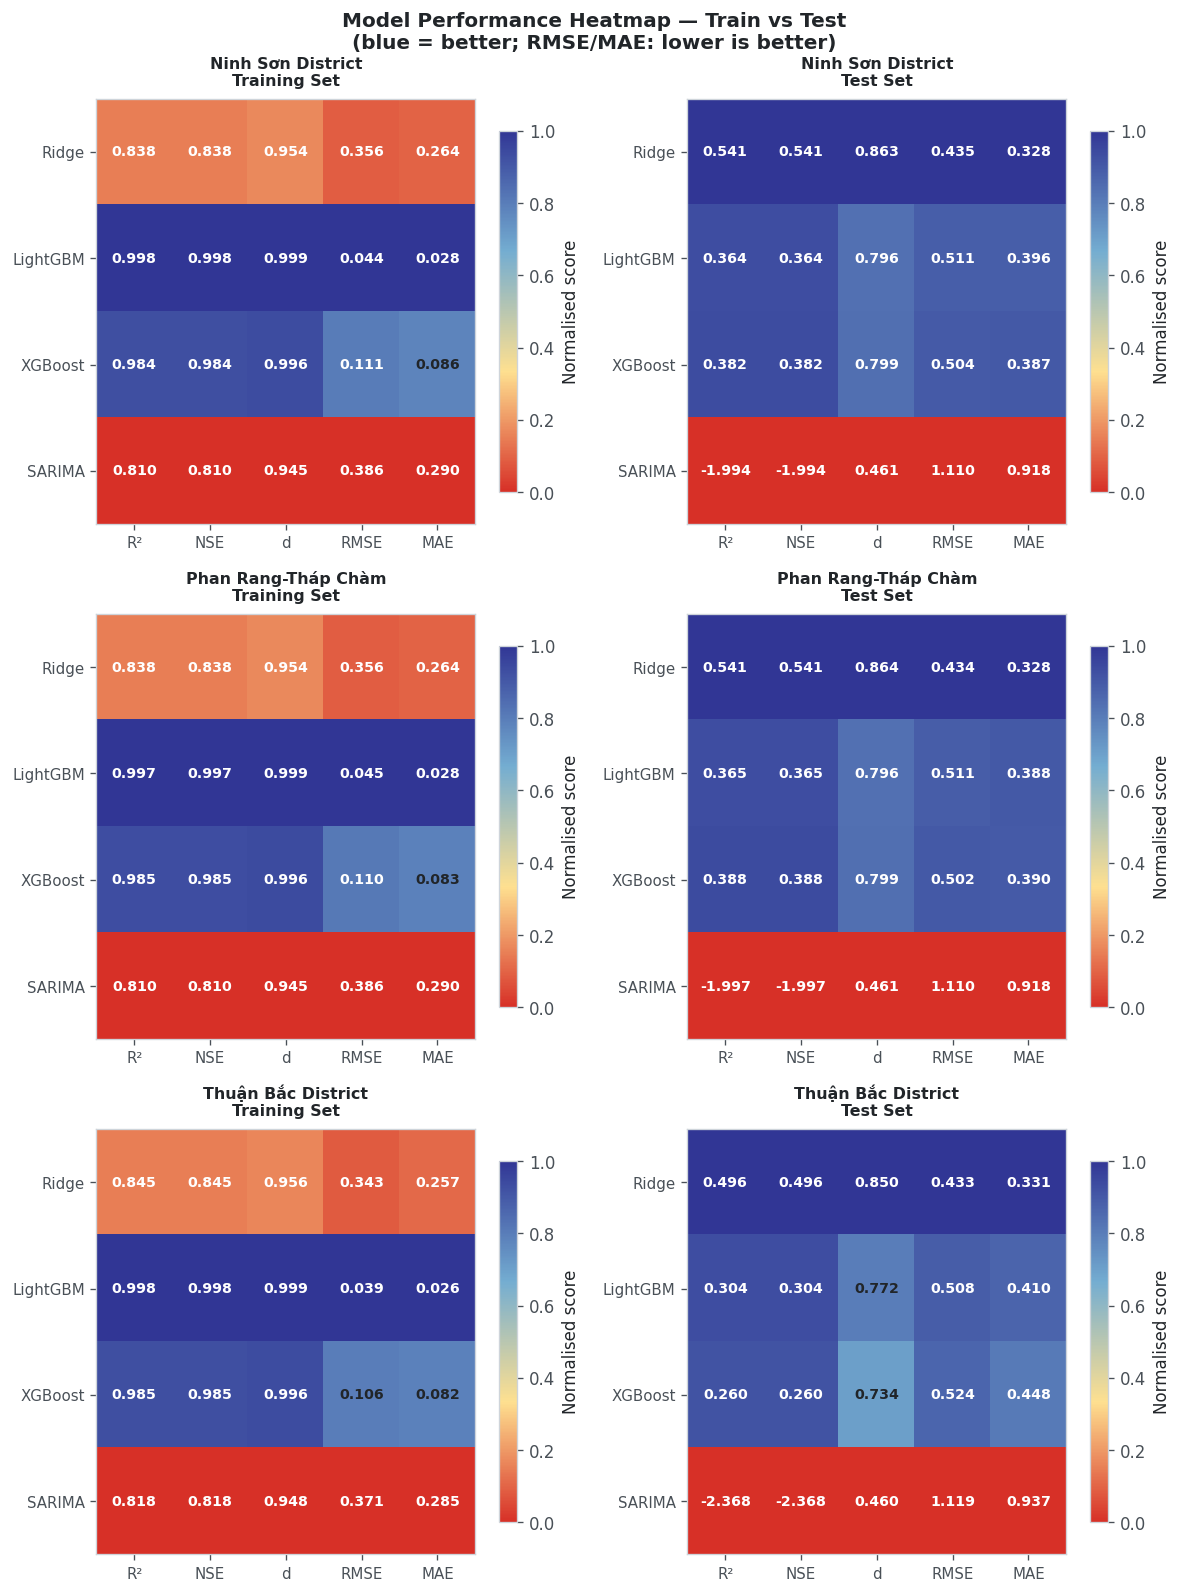

✅ Figure 4 saved


In [10]:
# Cell 11 — Advanced performance heatmap: Train vs Test for every location
METRIC_COLS = ["R²", "NSE", "d", "RMSE", "MAE"]
MODEL_NAMES = ["Ridge", "LightGBM", "XGBoost", "SARIMA"]

n_locs = len(LOCATIONS)
fig, axes = plt.subplots(n_locs, 2,
                         figsize=(10, 4.5 * n_locs),
                         facecolor="white")
if n_locs == 1:
    axes = axes.reshape(1, -1)

cmap_light = LinearSegmentedColormap.from_list(
    "perf", ["#d73027", "#fee090", "#74add1", "#313695"])

for row, loc in enumerate(LOCATIONS):
    for col_idx, (label, res_dict) in enumerate([
            ("Training Set", train_results[loc]),
            ("Test Set",     results[loc])]):

        ax = axes[row, col_idx]
        data = np.array([[res_dict[m]["metrics"][c]
                          for c in METRIC_COLS]
                         for m in MODEL_NAMES], dtype=float)

        norm_data = data.copy()
        for ci, c in enumerate(METRIC_COLS):
            cv = data[:, ci]
            lo, hi = np.nanmin(cv), np.nanmax(cv)
            if hi > lo:
                if c in ("RMSE", "MAE"):
                    norm_data[:, ci] = (hi - cv) / (hi - lo)
                else:
                    norm_data[:, ci] = (cv - lo) / (hi - lo)
            else:
                norm_data[:, ci] = 0.5

        im = ax.imshow(norm_data, cmap=cmap_light, vmin=0, vmax=1, aspect="auto")

        ax.set_xticks(range(len(METRIC_COLS)))
        ax.set_xticklabels(METRIC_COLS, fontsize=9)
        ax.set_yticks(range(len(MODEL_NAMES)))
        ax.set_yticklabels(MODEL_NAMES, fontsize=9)
        ax.set_title(f"{loc[:30]}\n{label}", fontsize=9.5, pad=8)

        for ri, mname in enumerate(MODEL_NAMES):
            for ci, c in enumerate(METRIC_COLS):
                val  = data[ri, ci]
                nval = norm_data[ri, ci]
                txt_col = "white" if nval < 0.35 or nval > 0.80 else "#212529"
                ax.text(ci, ri, f"{val:.3f}", ha="center", va="center",
                        color=txt_col, fontsize=8.5, fontweight="bold")

        plt.colorbar(im, ax=ax, shrink=0.85, label="Normalised score")

plt.suptitle("Model Performance Heatmap — Train vs Test\n"
             "(blue = better; RMSE/MAE: lower is better)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_04_metrics_heatmap.png", **SAVEFIG_KW)
plt.show()
print("✅ Figure 4 saved")


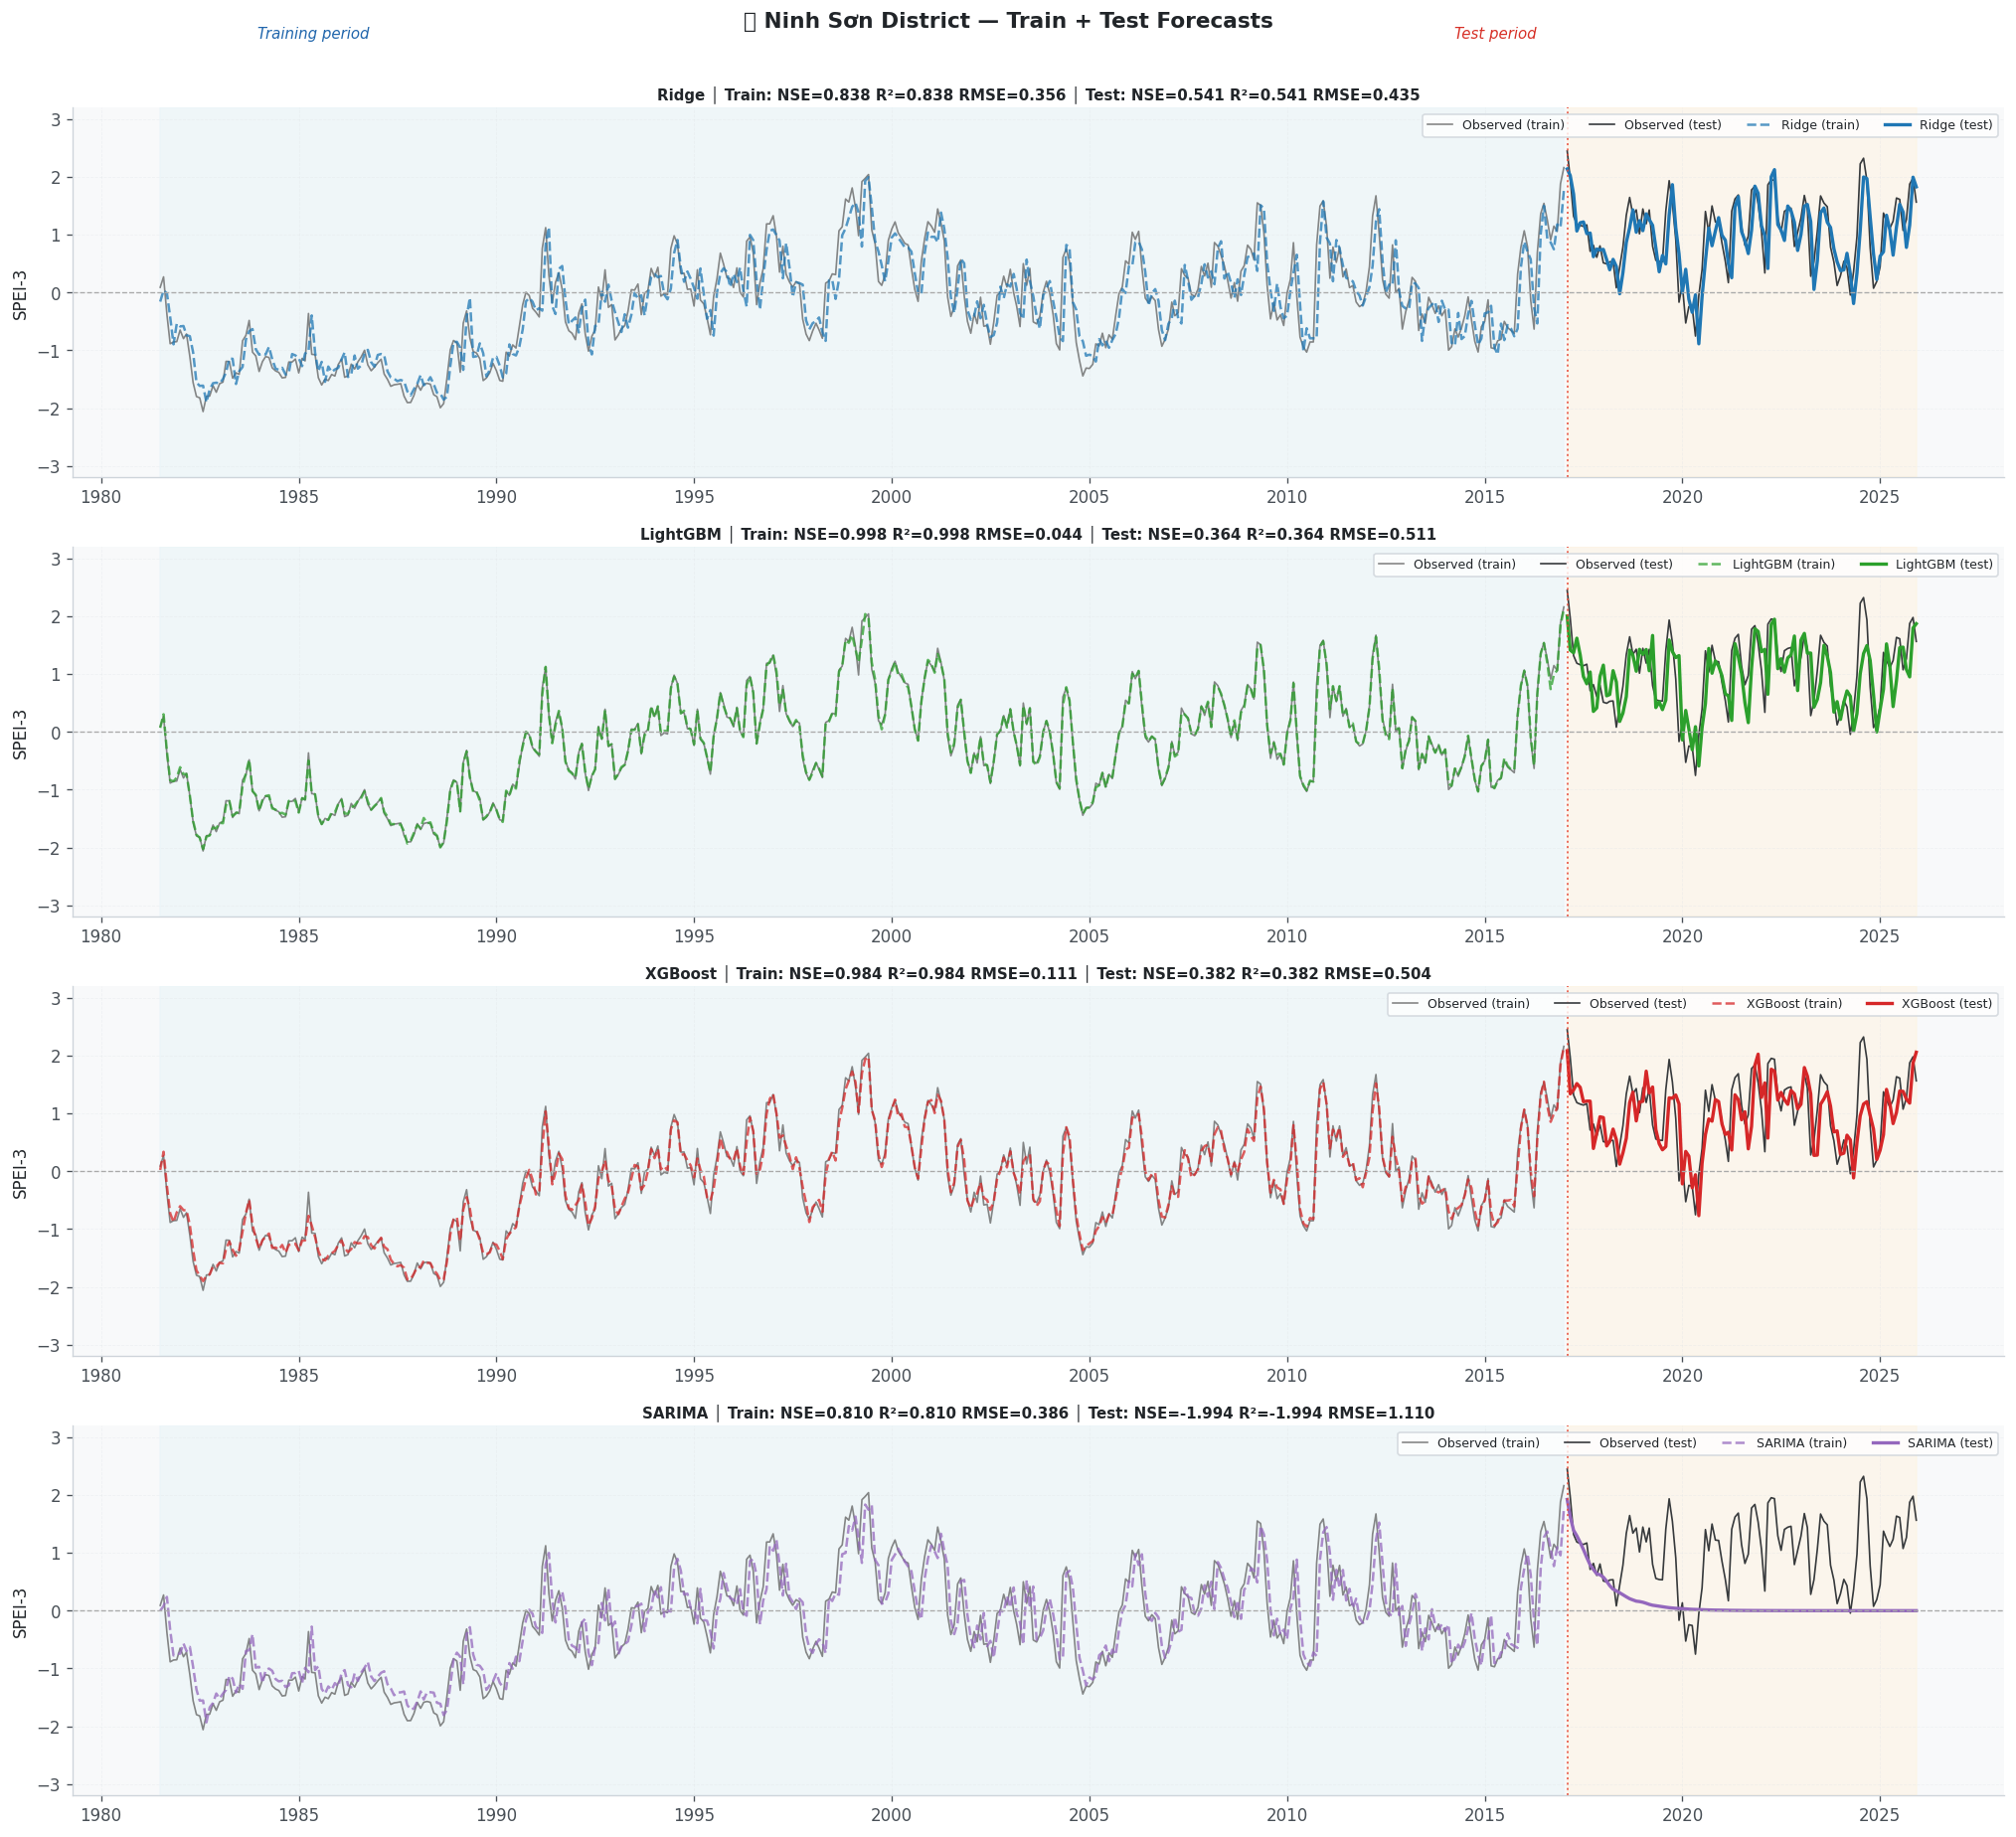

✅ Saved fig_05_forecast_Ninh_Sơn_District.png


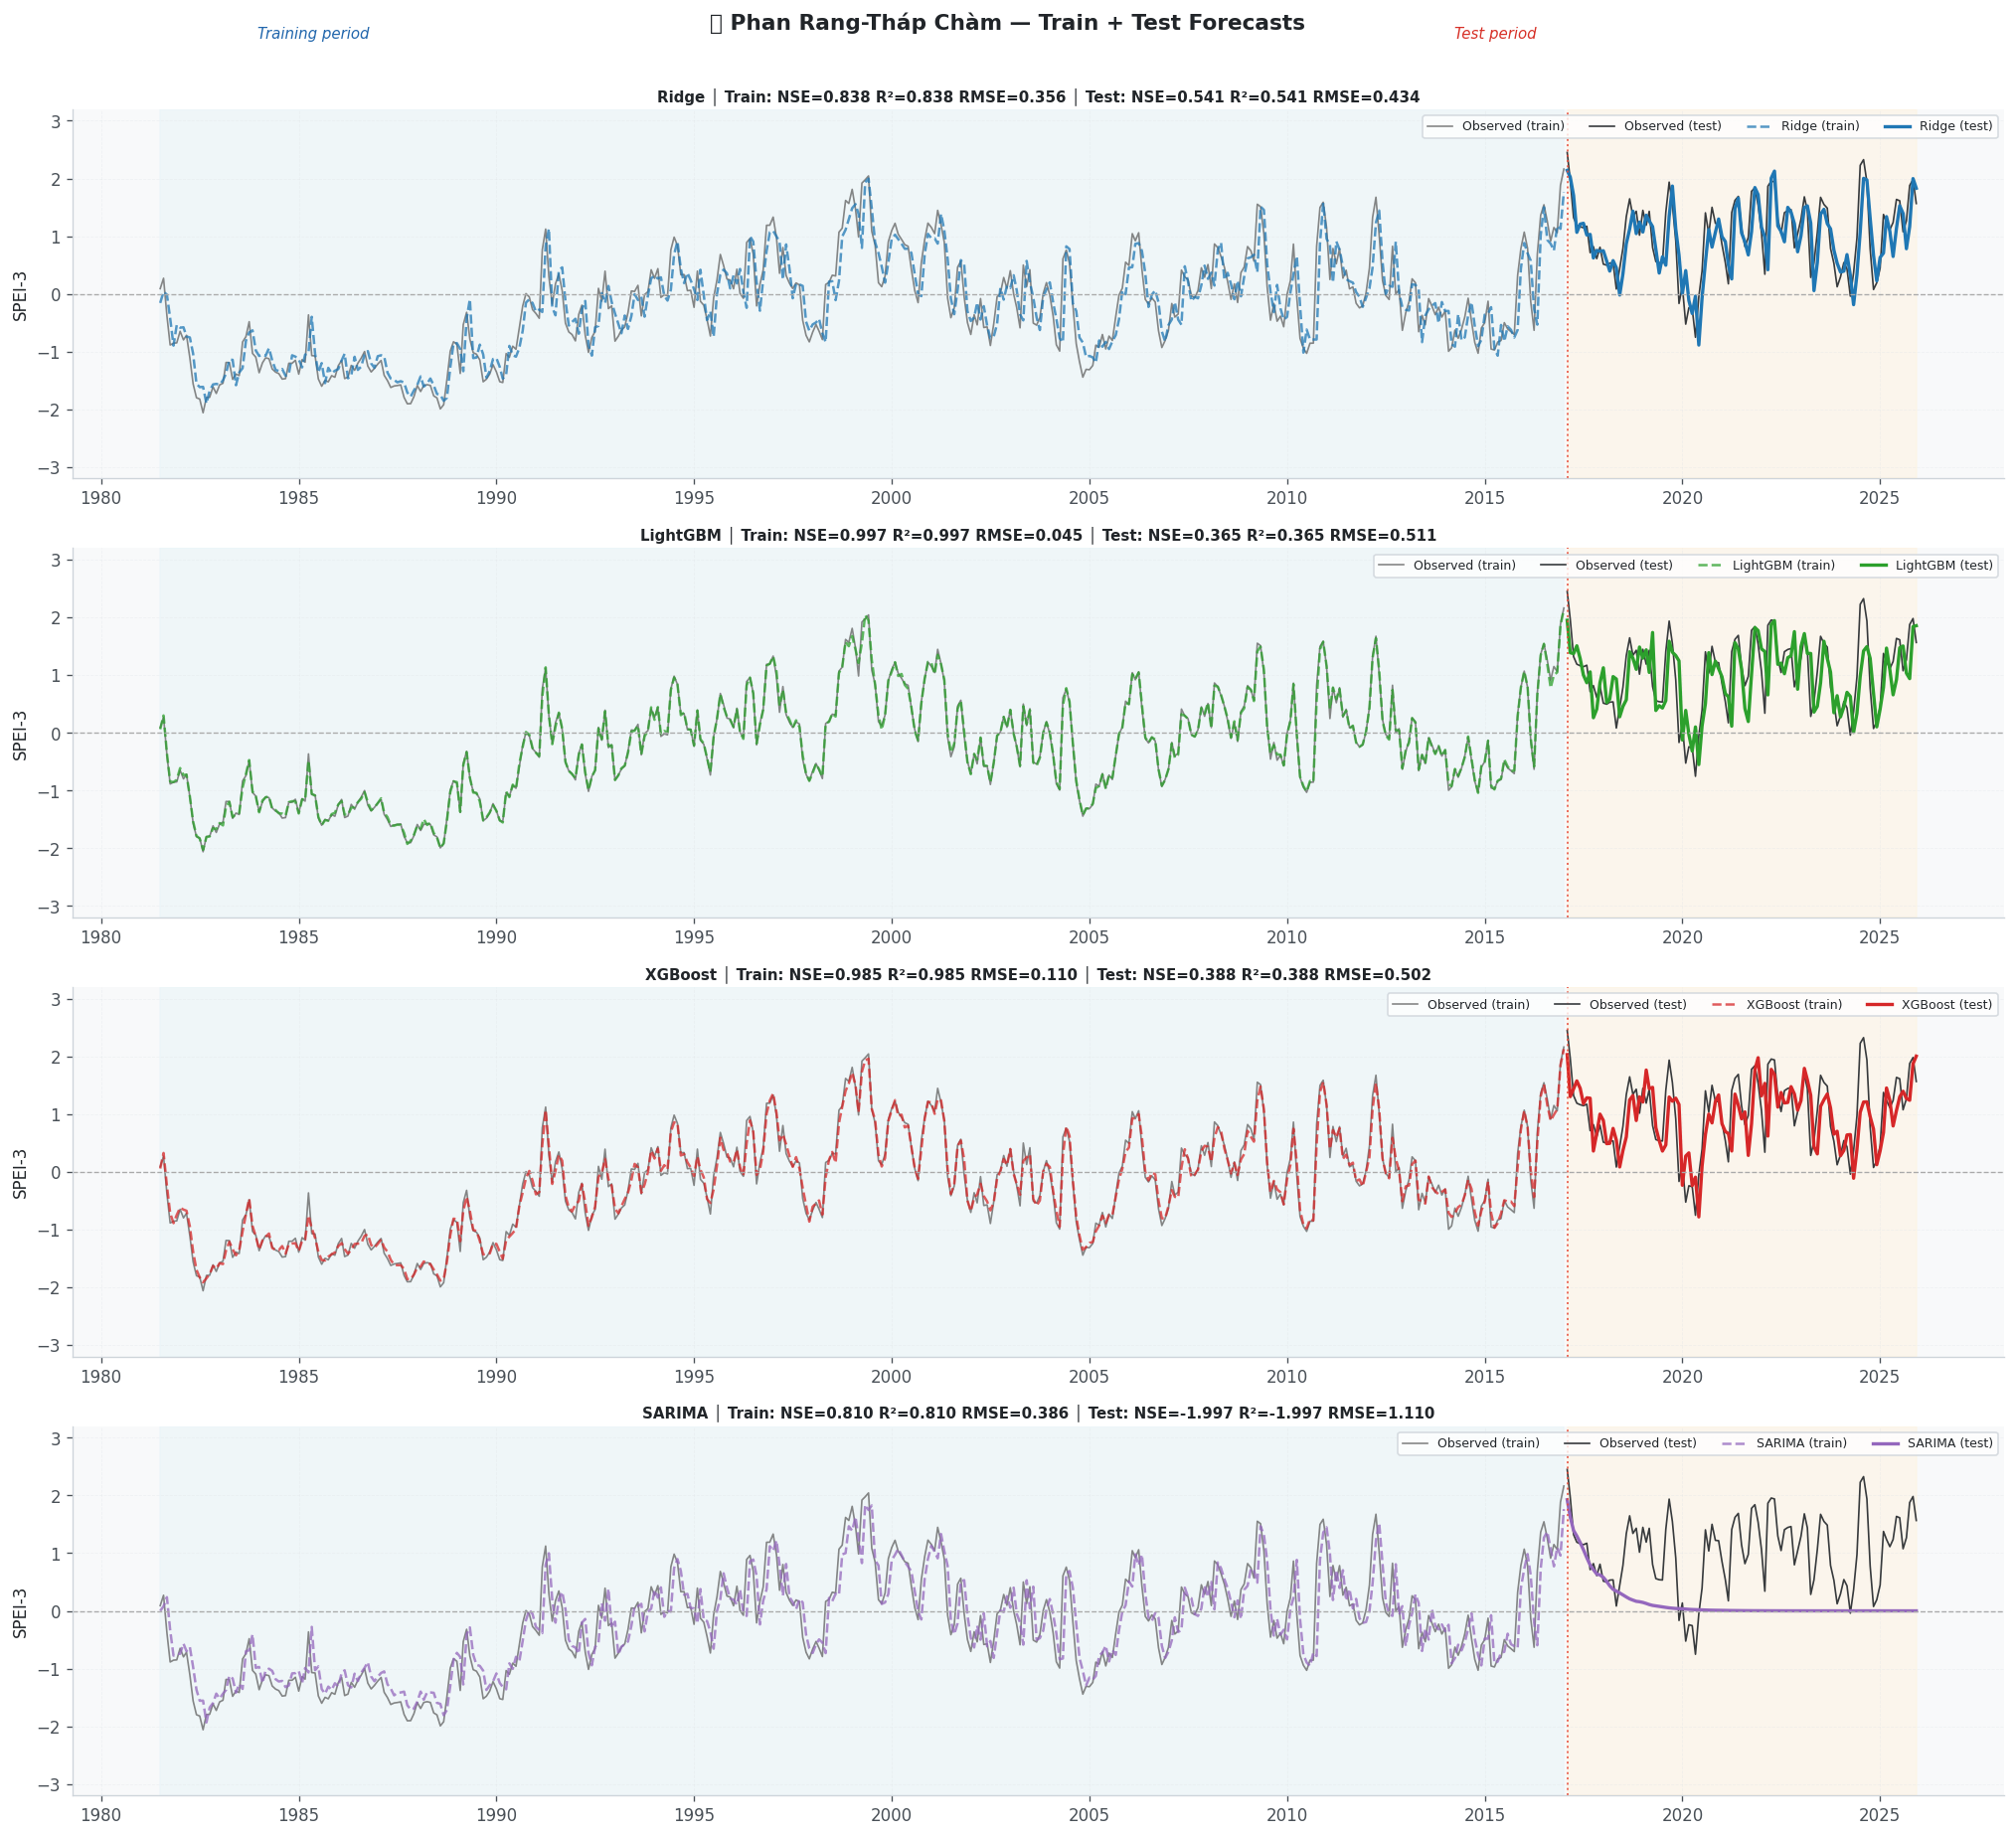

✅ Saved fig_05_forecast_Phan_Rang-Tháp_Chàm.png


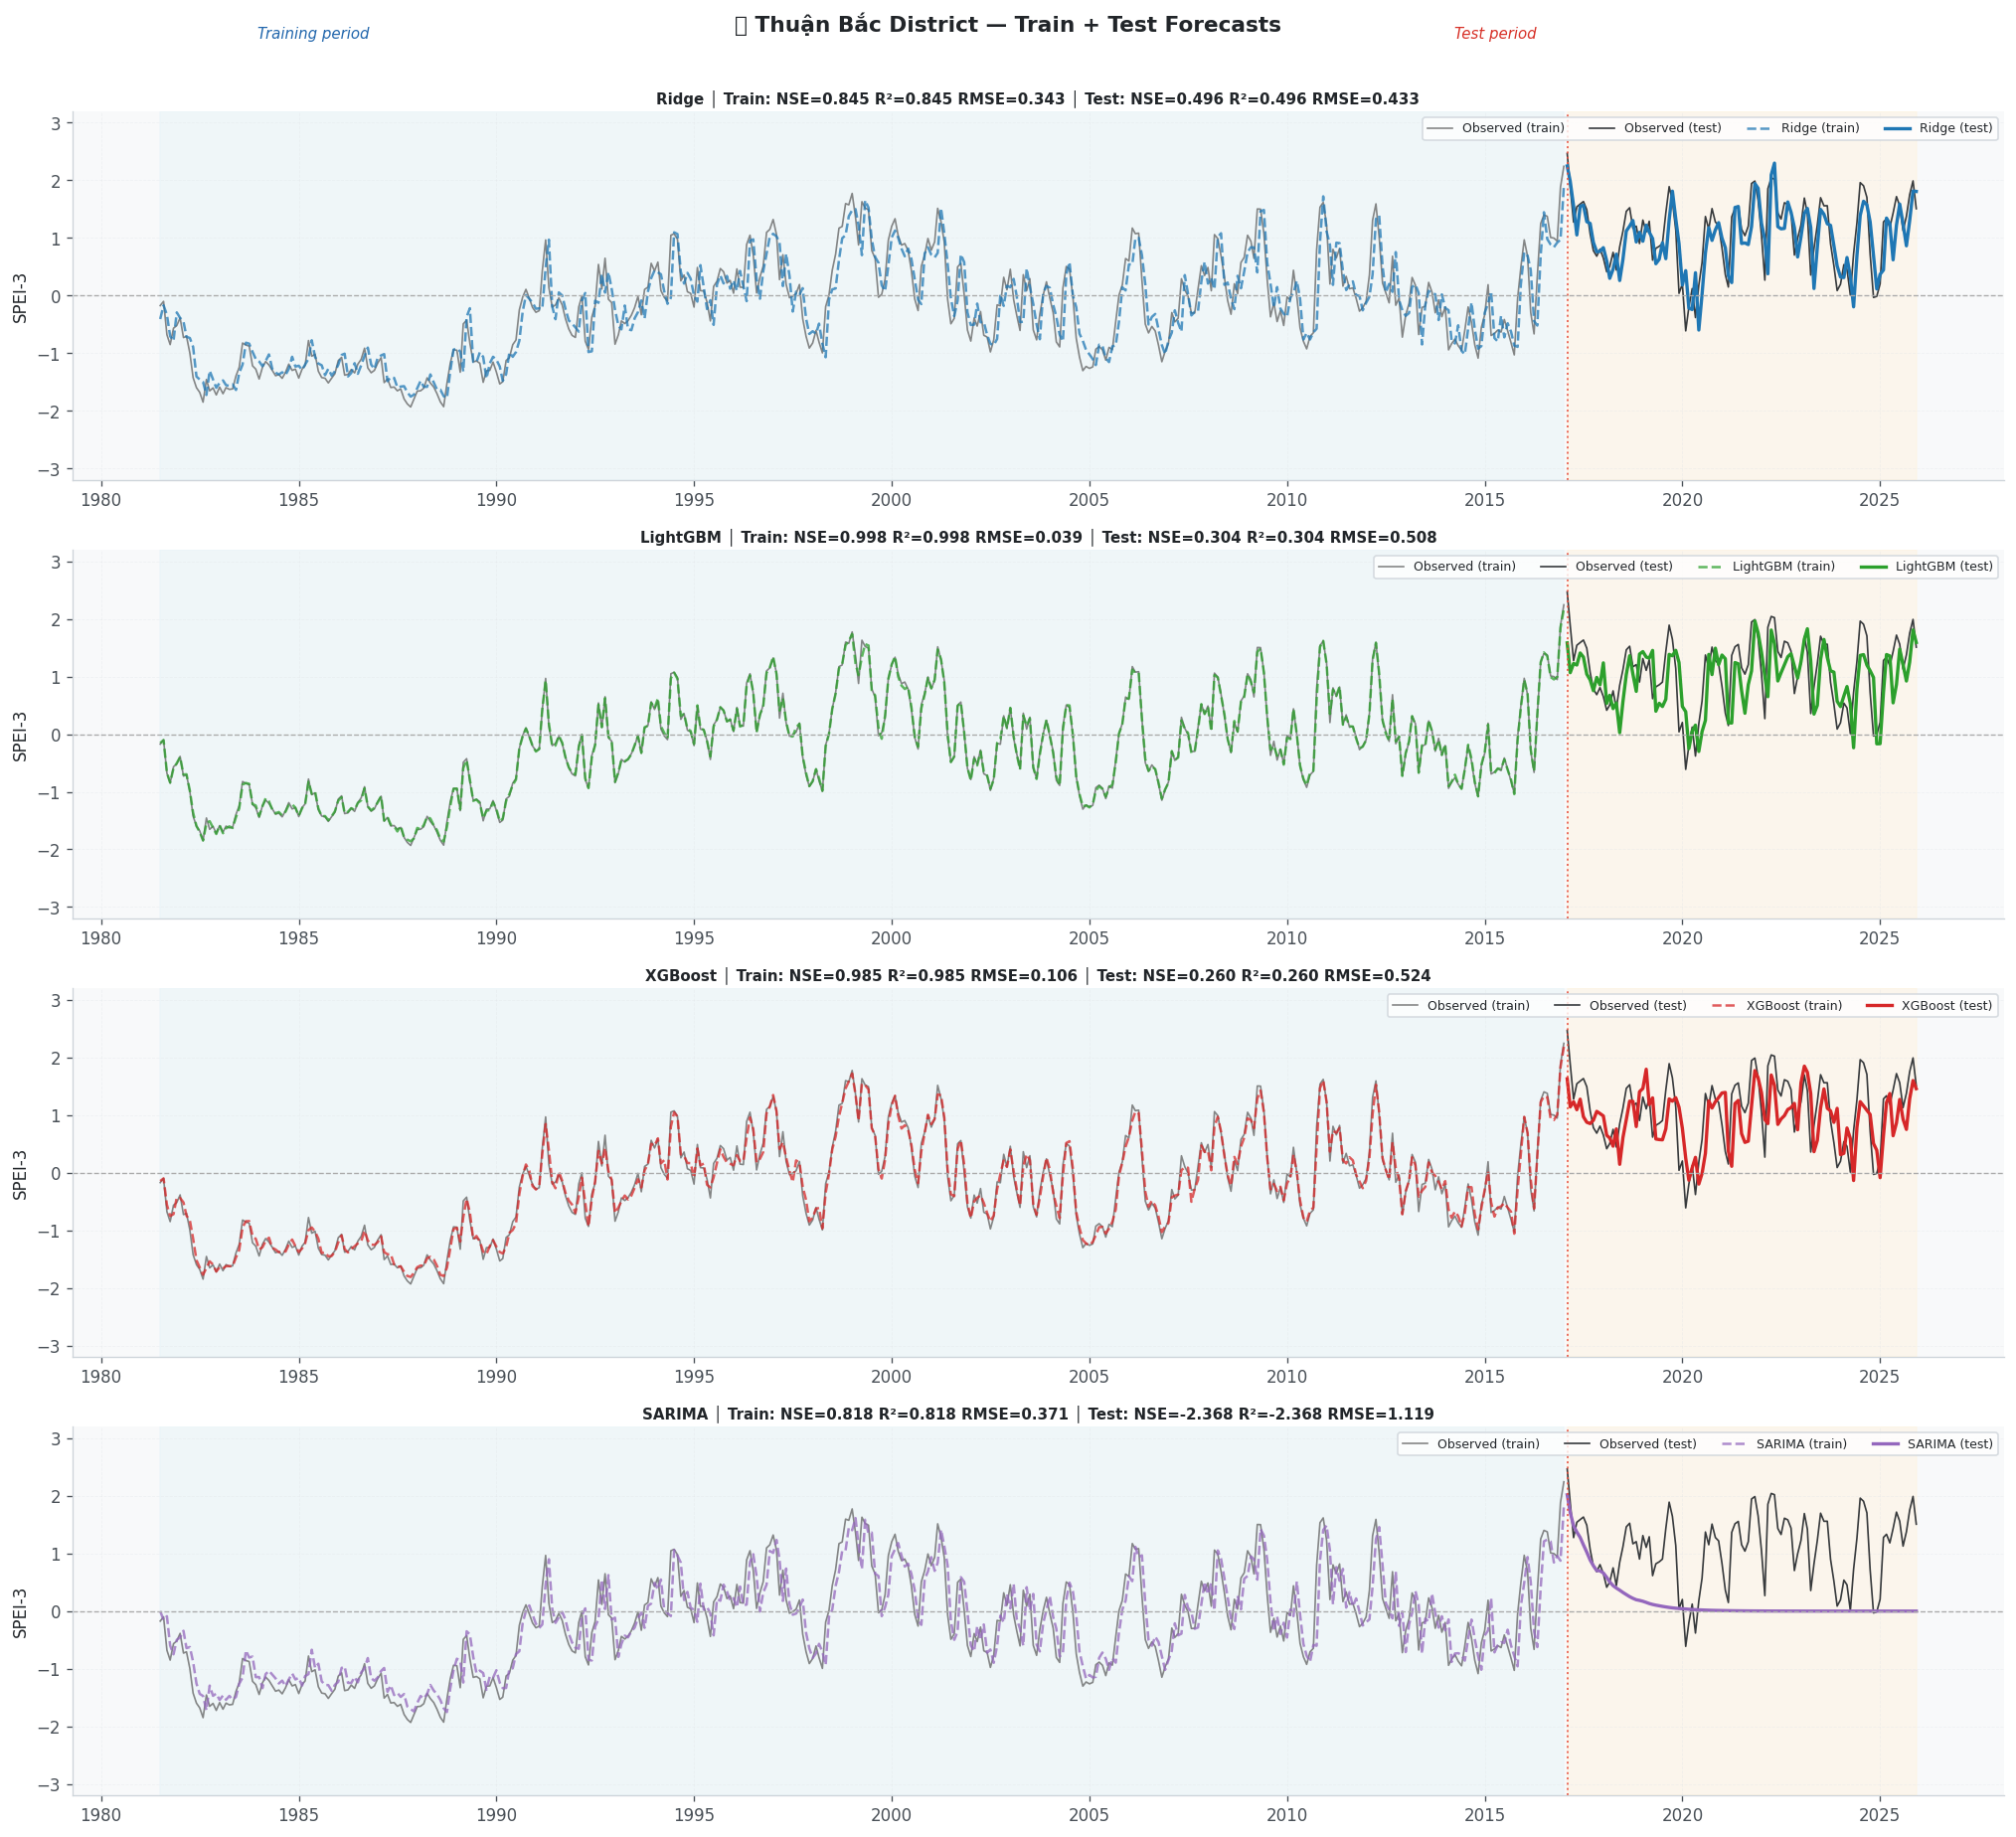

✅ Saved fig_05_forecast_Thuận_Bắc_District.png


In [11]:
# Cell 12 — Forecast vs Observed: Train + Test comparison (light theme)
for loc in LOCATIONS:
    sp    = splits[loc]
    y_tr  = sp["y_tr"];  idx_tr = sp["idx_tr"]
    y_te  = sp["y_te"];  idx_te = sp["idx_te"]

    fig, axes = plt.subplots(len(MODEL_NAMES), 1,
                             figsize=(17, 3.8 * len(MODEL_NAMES)),
                             facecolor="white")

    for ax, (mname, col) in zip(axes, zip(MODEL_NAMES, PAL)):
        pred_tr = train_results[loc][mname]["pred"]
        pred_te = results[loc][mname]["pred"]
        n_tr = min(len(idx_tr), len(pred_tr))
        n_te = min(len(idx_te), len(pred_te))

        # Training region shading
        ax.axvspan(idx_tr[0], idx_tr[-1], color="#e8f4f8", alpha=0.5, label="_nolegend_")
        ax.axvspan(idx_te[0], idx_te[-1], color="#fff3e0", alpha=0.5, label="_nolegend_")

        # Observed
        ax.plot(idx_tr[:n_tr], y_tr[:n_tr], color="#555555", lw=1.0, alpha=0.7, label="Observed (train)")
        ax.plot(idx_te[:n_te], y_te[:n_te], color="#212529", lw=1.0, alpha=0.9, label="Observed (test)")

        # Predictions
        ax.plot(idx_tr[:n_tr], pred_tr[:n_tr], color=col, lw=1.5, ls="--",
                alpha=0.75, label=f"{mname} (train)")
        ax.plot(idx_te[:n_te], pred_te[:n_te], color=col, lw=2.0,
                label=f"{mname} (test)")

        # Vertical split line
        ax.axvline(idx_te[0], color="#e74c3c", lw=1.2, ls=":", alpha=0.8)

        m_tr = train_results[loc][mname]["metrics"]
        m_te = results[loc][mname]["metrics"]
        ax.set_title(
            f"{mname} │ Train: NSE={m_tr['NSE']:.3f} R²={m_tr['R²']:.3f} RMSE={m_tr['RMSE']:.3f} "
            f"│ Test: NSE={m_te['NSE']:.3f} R²={m_te['R²']:.3f} RMSE={m_te['RMSE']:.3f}",
            fontsize=9, pad=5)
        ax.axhline(0, color="#aaaaaa", lw=0.8, ls="--")
        ax.set_ylim(-3.2, 3.2)
        ax.legend(fontsize=7.5, ncol=4, loc="upper right")
        ax.grid(True, alpha=0.35)
        ax.set_ylabel("SPEI-3")
        ax.spines[["top","right"]].set_visible(False)

    fig.text(0.13, 0.995, "Training period", fontsize=9, color="#2166ac", style="italic")
    fig.text(0.72, 0.995, "Test period", fontsize=9, color="#d73027", style="italic")
    plt.suptitle(f"📍 {loc} — Train + Test Forecasts", fontsize=13,
                 fontweight="bold", y=1.01)
    plt.tight_layout()
    fname = f"fig_05_forecast_{loc.replace(' ', '_')}.png"
    plt.savefig(fname, **SAVEFIG_KW)
    plt.show()
    print(f"✅ Saved {fname}")


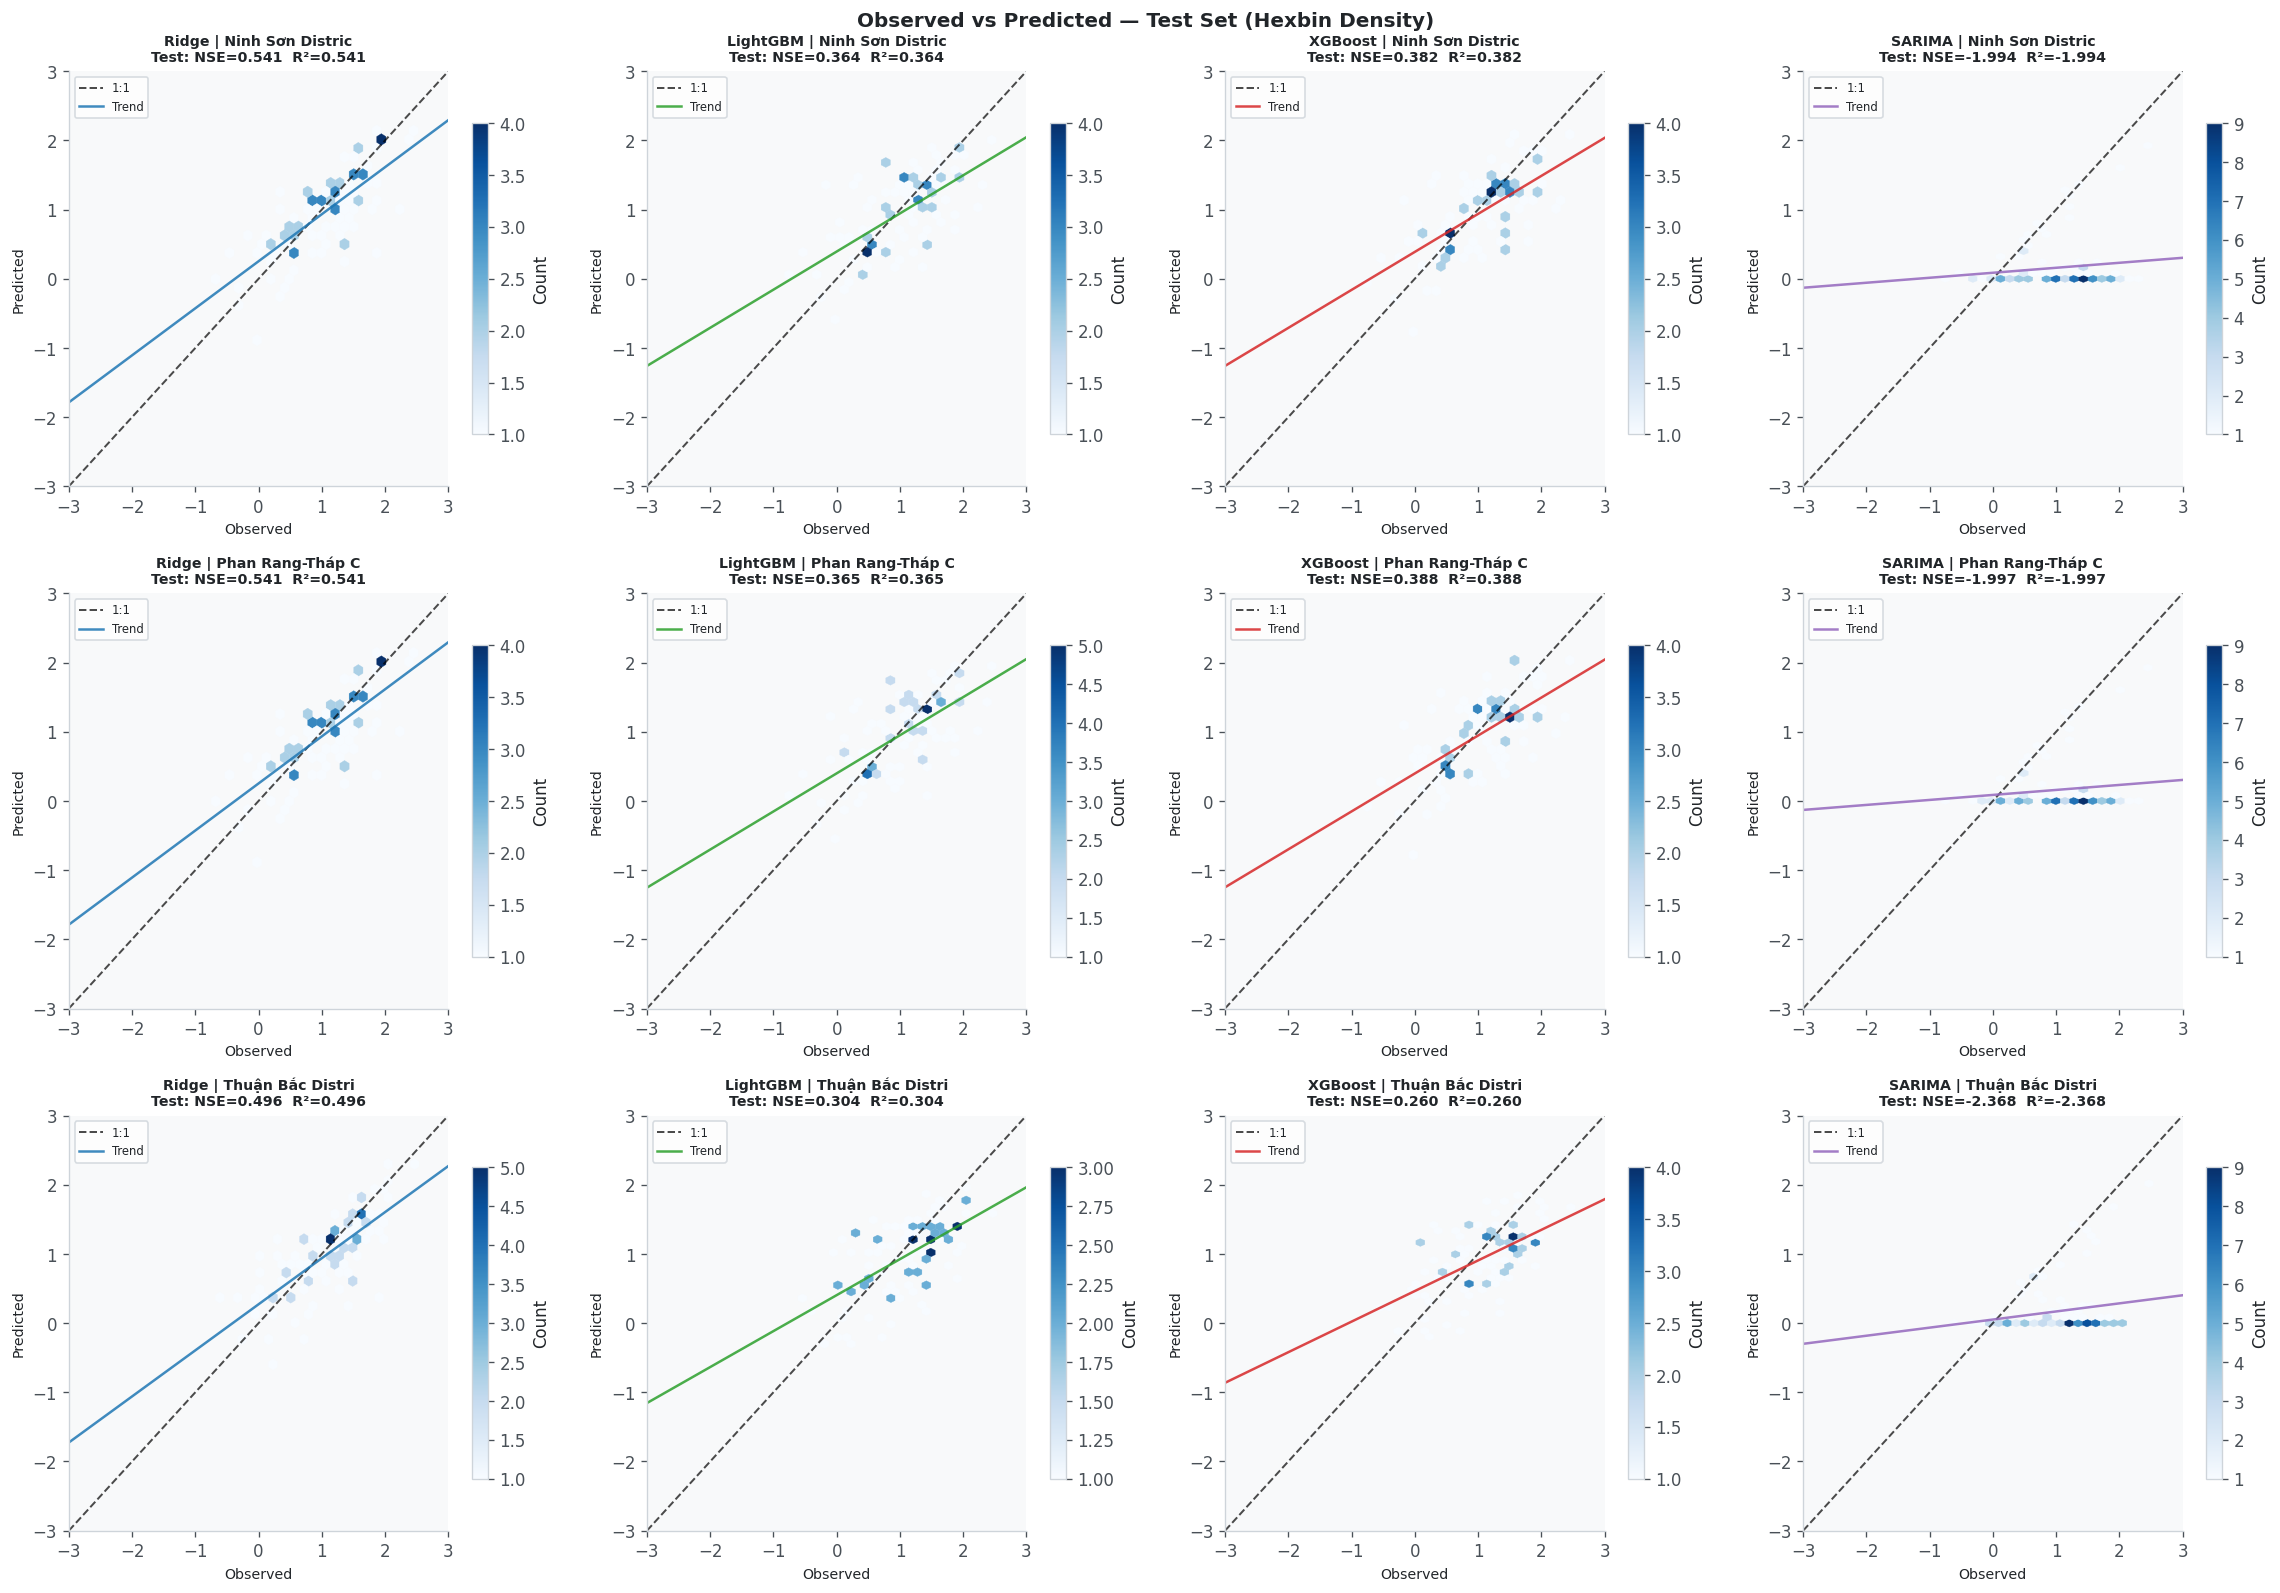

✅ Figure 6 saved


In [12]:
# Cell 13 — Observed vs Predicted scatter with marginal histograms (light theme)
fig, axes = plt.subplots(len(LOCATIONS), len(MODEL_NAMES),
                         figsize=(4.8 * len(MODEL_NAMES), 4.5 * len(LOCATIONS)),
                         facecolor="white")
if len(LOCATIONS) == 1:
    axes = axes.reshape(1, -1)

for i, loc in enumerate(LOCATIONS):
    y_te = splits[loc]["y_te"]
    for j, (mname, col) in enumerate(zip(MODEL_NAMES, PAL)):
        ax = axes[i, j]
        pred = results[loc][mname]["pred"]
        n    = min(len(y_te), len(pred))
        obs_n  = y_te[:n]
        pred_n = pred[:n]
        # Hexbin for density
        hb = ax.hexbin(obs_n, pred_n, gridsize=22, cmap="Blues",
                       linewidths=0.2, mincnt=1)
        plt.colorbar(hb, ax=ax, shrink=0.75, label="Count")
        # 1:1 line
        lims = (-3, 3)
        ax.plot(lims, lims, "k--", lw=1.2, alpha=0.7, label="1:1")
        # Regression line
        z = np.polyfit(obs_n, pred_n, 1)
        p = np.poly1d(z)
        xs_fit = np.linspace(-3, 3, 100)
        ax.plot(xs_fit, p(xs_fit), color=col, lw=1.5, ls="-", alpha=0.85, label="Trend")
        m  = results[loc][mname]["metrics"]
        m_tr = train_results[loc][mname]["metrics"]
        ax.set_title(f"{mname} | {loc[:16]}\n"
                     f"Test: NSE={m['NSE']:.3f}  R²={m['R²']:.3f}", fontsize=8.5)
        ax.set_xlabel("Observed", fontsize=8.5)
        ax.set_ylabel("Predicted", fontsize=8.5)
        ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
        ax.legend(fontsize=7, loc="upper left")
        ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Observed vs Predicted — Test Set (Hexbin Density)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_06_scatter.png", **SAVEFIG_KW)
plt.show()
print("✅ Figure 6 saved")


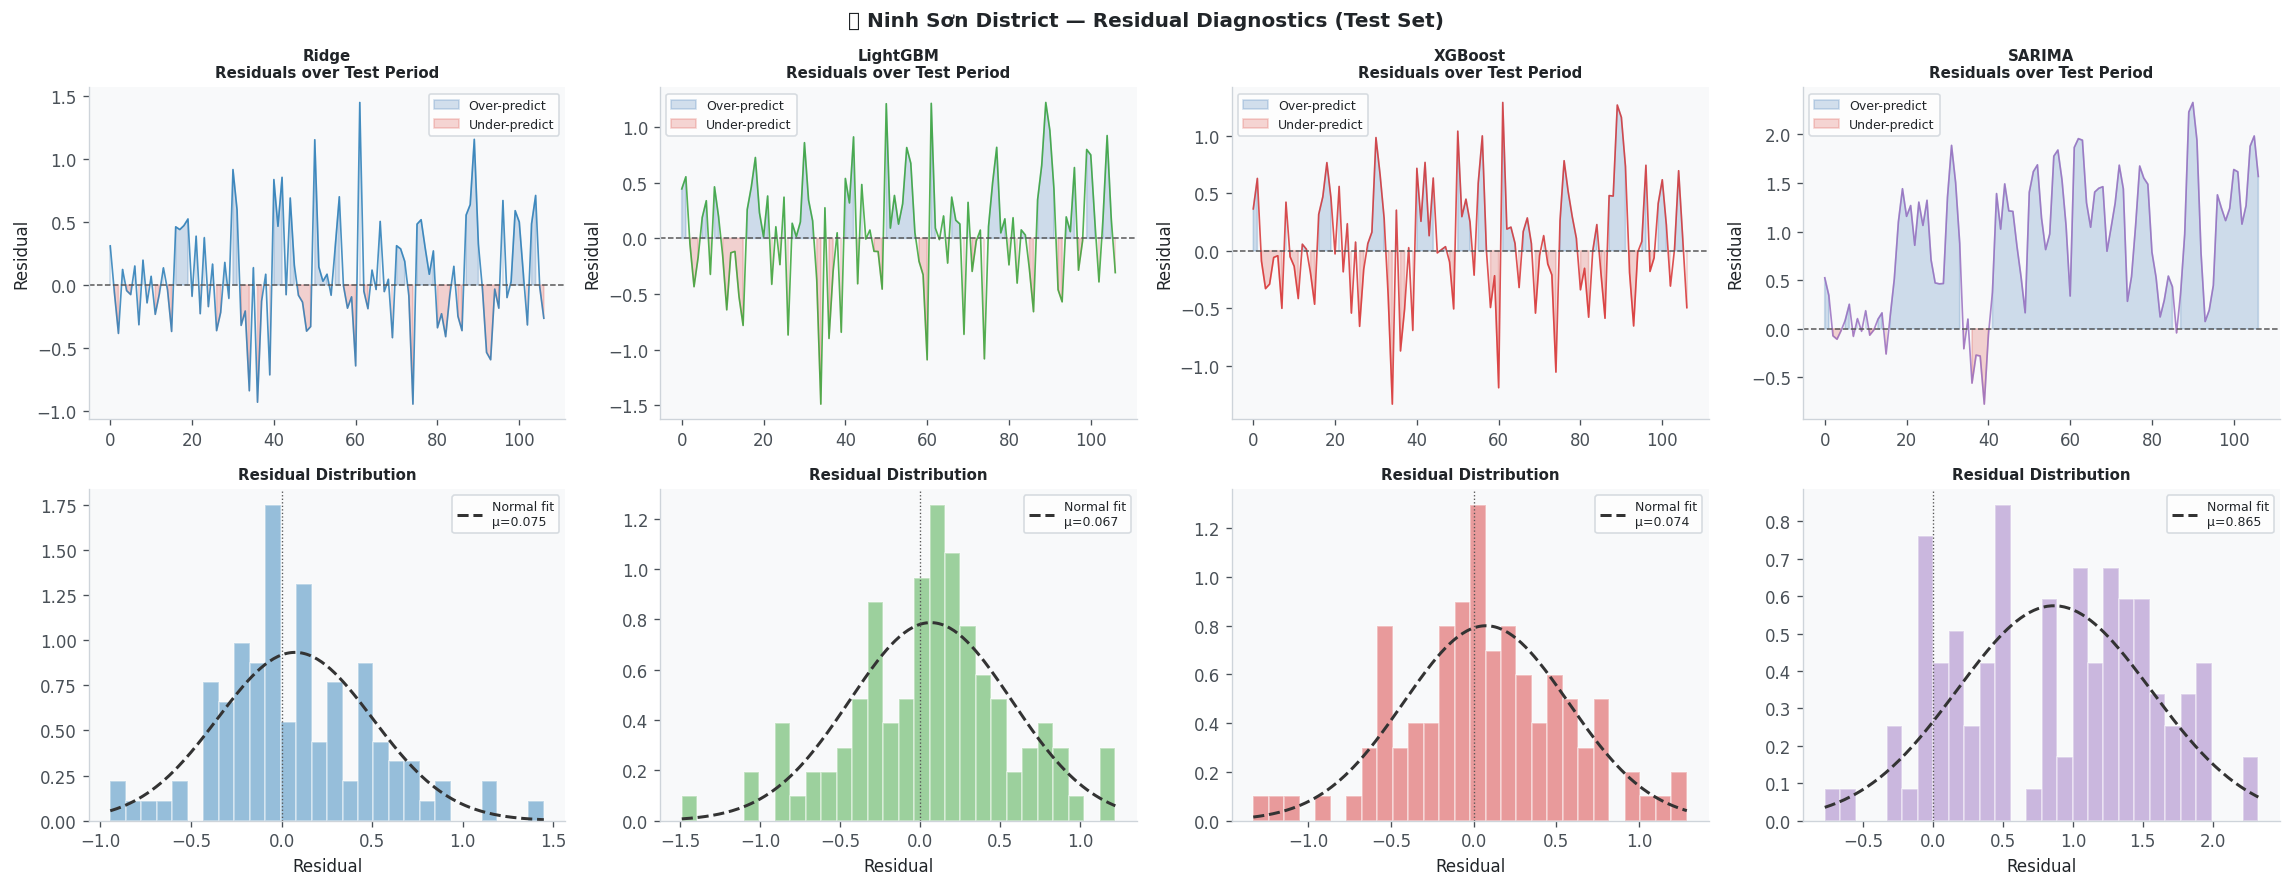

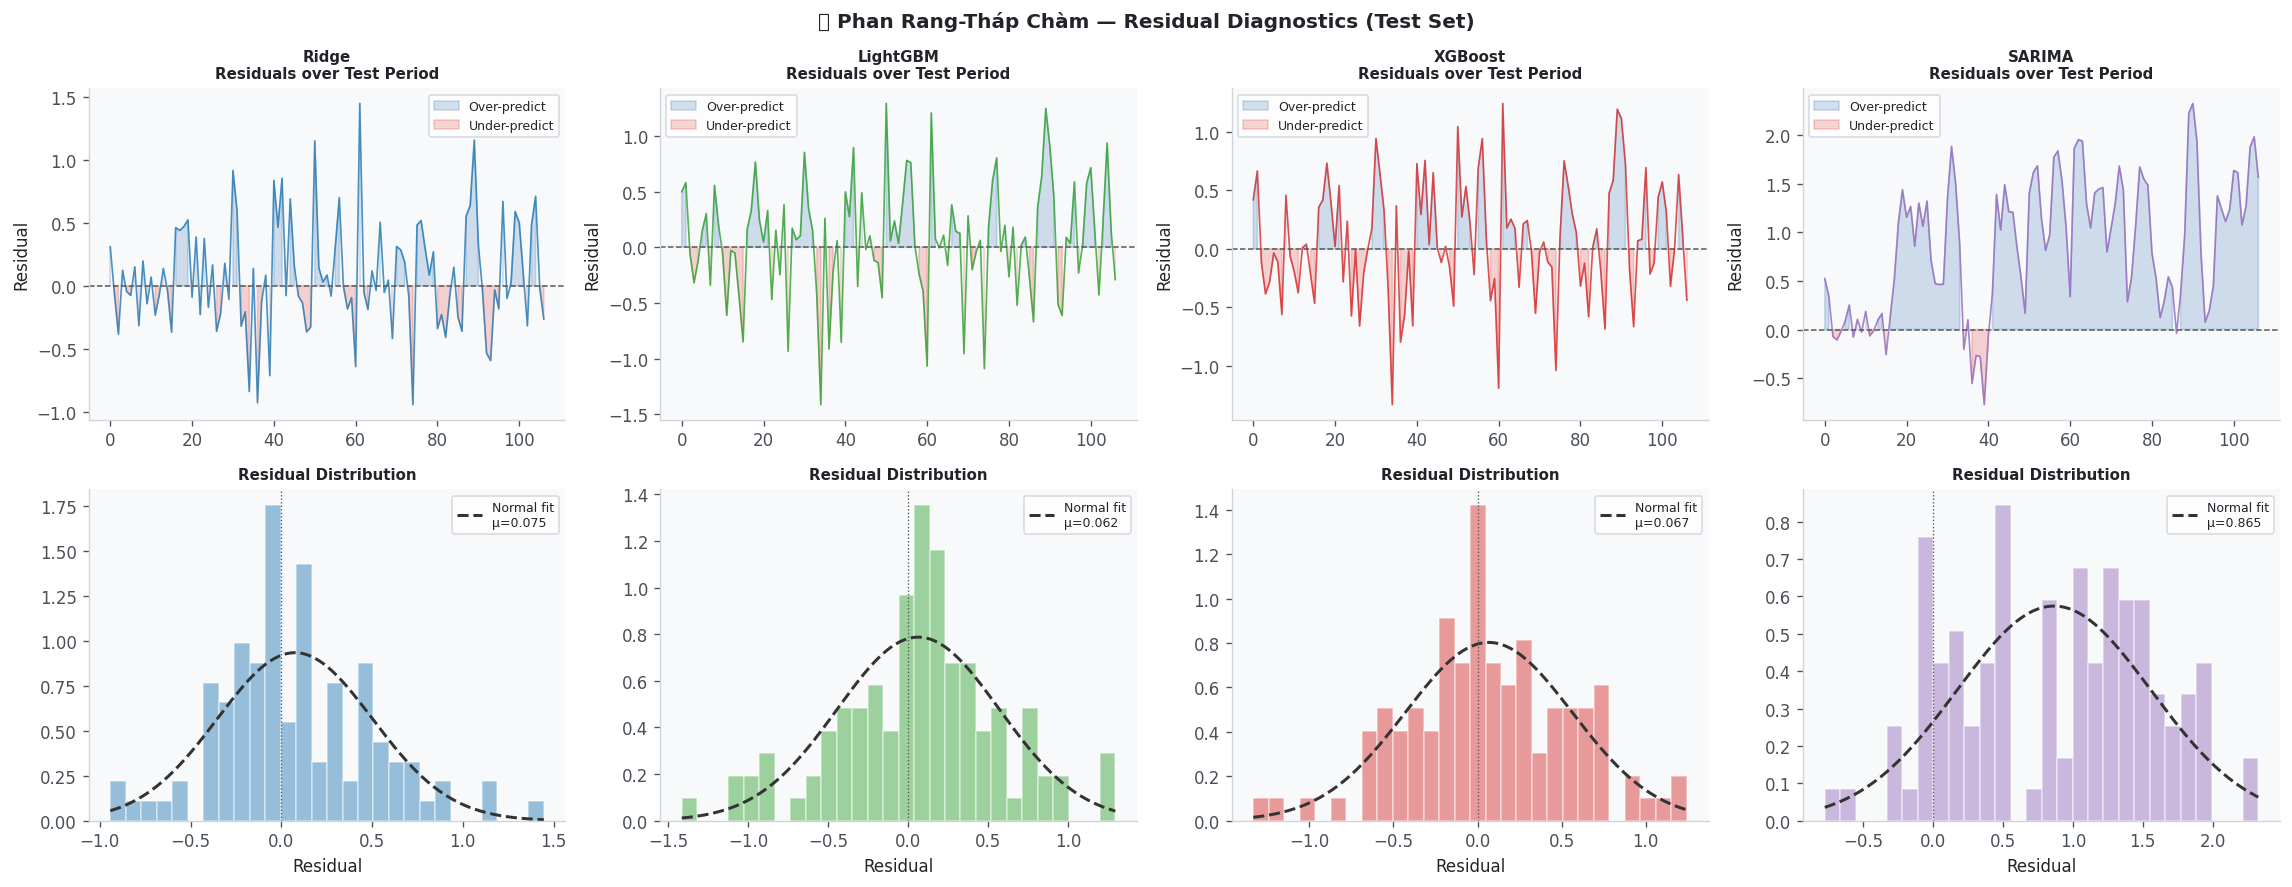

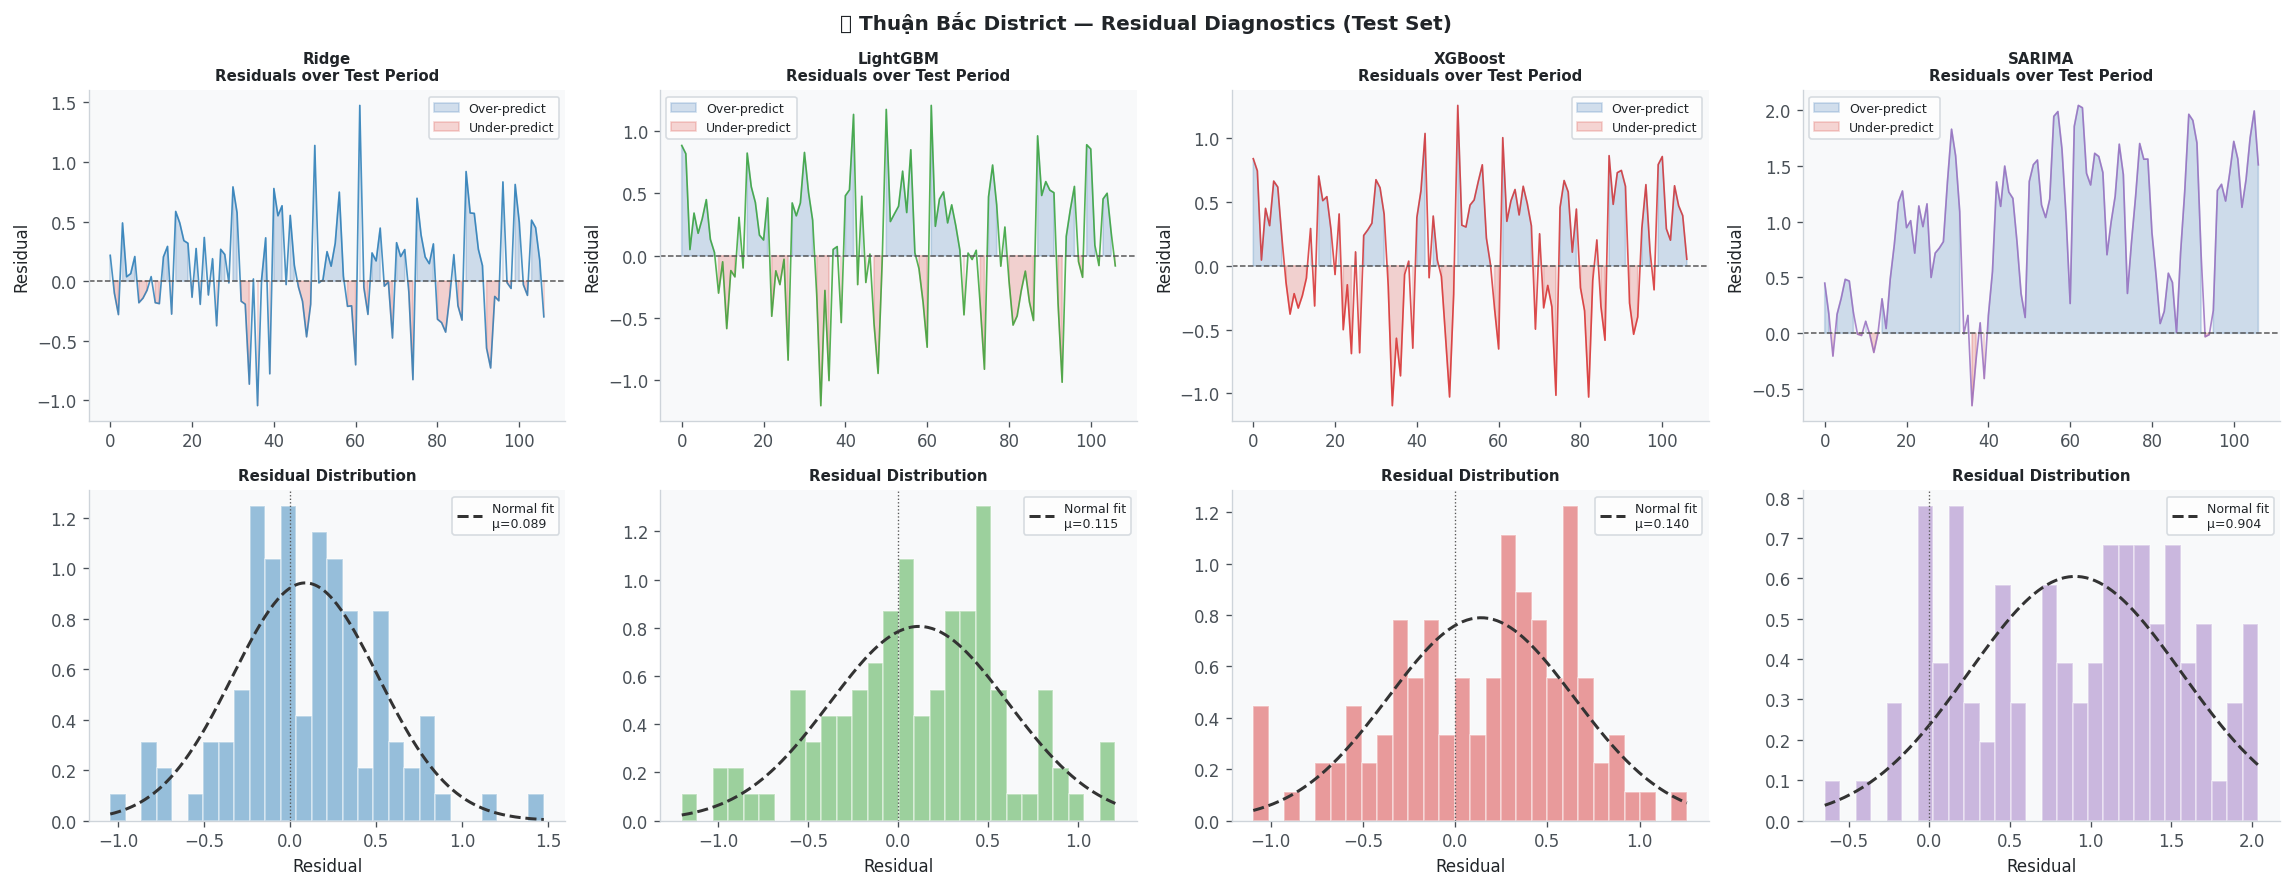

✅ Residual figures saved


In [13]:
# Cell 14 — Residual diagnostics (light theme)
from scipy.stats import norm as sp_norm

for loc in LOCATIONS:
    y_te = splits[loc]["y_te"]
    fig, axes = plt.subplots(2, len(MODEL_NAMES),
                             figsize=(4.8 * len(MODEL_NAMES), 7.5),
                             facecolor="white")

    for j, (mname, col) in enumerate(zip(MODEL_NAMES, PAL)):
        pred = results[loc][mname]["pred"]
        n    = min(len(y_te), len(pred))
        res  = y_te[:n] - pred[:n]

        # Residual over time
        ax1 = axes[0, j]
        ax1.plot(res, color=col, lw=1, alpha=0.8)
        ax1.axhline(0, color="#555555", lw=0.9, ls="--")
        ax1.fill_between(range(len(res)), res, 0,
                         where=(res > 0), color="#2166ac", alpha=0.2, label="Over-predict")
        ax1.fill_between(range(len(res)), res, 0,
                         where=(res < 0), color="#d73027", alpha=0.2, label="Under-predict")
        ax1.set_title(f"{mname}\nResiduals over Test Period", fontsize=9)
        ax1.set_ylabel("Residual")
        ax1.legend(fontsize=7.5)
        ax1.spines[["top","right"]].set_visible(False)

        # Residual histogram + normal fit
        ax2 = axes[1, j]
        ax2.hist(res, bins=28, color=col, alpha=0.45, density=True,
                 edgecolor="white", lw=0.3)
        xs = np.linspace(res.min(), res.max(), 200)
        ax2.plot(xs, sp_norm.pdf(xs, res.mean(), res.std()),
                 color="#333333", lw=1.8, ls="--", label=f"Normal fit\nμ={res.mean():.3f}")
        ax2.axvline(0, color="#555555", lw=0.8, ls=":")
        ax2.set_title("Residual Distribution", fontsize=9)
        ax2.set_xlabel("Residual")
        ax2.legend(fontsize=7.5)
        ax2.spines[["top","right"]].set_visible(False)

    plt.suptitle(f"📍 {loc} — Residual Diagnostics (Test Set)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    fname = f"fig_07_residuals_{loc.replace(' ', '_')}.png"
    plt.savefig(fname, **SAVEFIG_KW)
    plt.show()
print("✅ Residual figures saved")


In [14]:
# Cell 15 — Uncertainty: Conformal Prediction + Moving-Block Bootstrap
ALPHA    = 0.10
N_BOOTS  = 200
BLOCK_SZ = 12

unc_results = {}

for loc in LOCATIONS:
    sp   = splits[loc]
    y_tr = sp["y_tr"]; y_te = sp["y_te"]
    X_tr_s = sp["X_tr_s"]; X_te_s = sp["X_te_s"]
    unc_results[loc] = {"Conformal": {}, "Bootstrap": {}}

    CAL_FRAC = 0.2
    n_cal  = int(len(y_tr) * CAL_FRAC)
    X_cal  = X_tr_s[-n_cal:]; y_cal = y_tr[-n_cal:]

    for mname in ["Ridge", "LightGBM", "XGBoost"]:
        pred_cal  = models_fit[loc][mname].predict(X_cal)
        nonconf   = np.abs(y_cal - pred_cal)
        q_hat     = np.quantile(nonconf, 1 - ALPHA)
        pred_te   = results[loc][mname]["pred"]
        n = min(len(y_te), len(pred_te))
        lower = pred_te[:n] - q_hat
        upper = pred_te[:n] + q_hat
        coverage = np.mean((y_te[:n] >= lower) & (y_te[:n] <= upper))
        unc_results[loc]["Conformal"][mname] = {
            "lower": lower, "upper": upper, "coverage": coverage, "q_hat": q_hat}

    for mname in ["LightGBM", "Ridge"]:
        boot_preds = []
        for _ in range(N_BOOTS):
            n_tr = len(y_tr)
            blocks = []
            idx_b  = 0
            while idx_b < n_tr:
                start = np.random.randint(0, max(1, n_tr - BLOCK_SZ))
                blocks.extend(range(start, min(start + BLOCK_SZ, n_tr)))
                idx_b += BLOCK_SZ
            idx_b_arr = np.array(blocks[:n_tr])
            Xb = X_tr_s[idx_b_arr]; yb = y_tr[idx_b_arr]
            m_boot = (lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                        num_leaves=31, random_state=None, verbose=-1)
                      if mname == "LightGBM" else Ridge(alpha=1.0))
            m_boot.fit(Xb, yb)
            boot_preds.append(m_boot.predict(X_te_s)[:len(y_te)])
        boot_arr  = np.array(boot_preds)
        lower_b   = np.percentile(boot_arr, 5,  axis=0)
        upper_b   = np.percentile(boot_arr, 95, axis=0)
        n         = min(len(y_te), lower_b.shape[0])
        coverage  = np.mean((y_te[:n] >= lower_b[:n]) & (y_te[:n] <= upper_b[:n]))
        unc_results[loc]["Bootstrap"][mname] = {
            "lower": lower_b, "upper": upper_b, "coverage": coverage}

print("\n── Uncertainty Coverage Summary (target: 90%) ──")
for loc in LOCATIONS:
    for method in ["Conformal", "Bootstrap"]:
        for mname, data in unc_results[loc][method].items():
            tag = f"{method} ({mname})"
            print(f"  {loc:35s}  {tag:30s}  {90:>6}%  {data['coverage']*100:>8.1f}%")
print("\n✅ Uncertainty quantification complete")



── Uncertainty Coverage Summary (target: 90%) ──
  Ninh Sơn District                    Conformal (Ridge)                   90%      91.6%
  Ninh Sơn District                    Conformal (LightGBM)                90%      10.3%
  Ninh Sơn District                    Conformal (XGBoost)                 90%      39.3%
  Ninh Sơn District                    Bootstrap (LightGBM)                90%      51.4%
  Ninh Sơn District                    Bootstrap (Ridge)                   90%      22.4%
  Phan Rang-Tháp Chàm                  Conformal (Ridge)                   90%      91.6%
  Phan Rang-Tháp Chàm                  Conformal (LightGBM)                90%      13.1%
  Phan Rang-Tháp Chàm                  Conformal (XGBoost)                 90%      33.6%
  Phan Rang-Tháp Chàm                  Bootstrap (LightGBM)                90%      45.8%
  Phan Rang-Tháp Chàm                  Bootstrap (Ridge)                   90%      24.3%
  Thuận Bắc District                   Conformal (

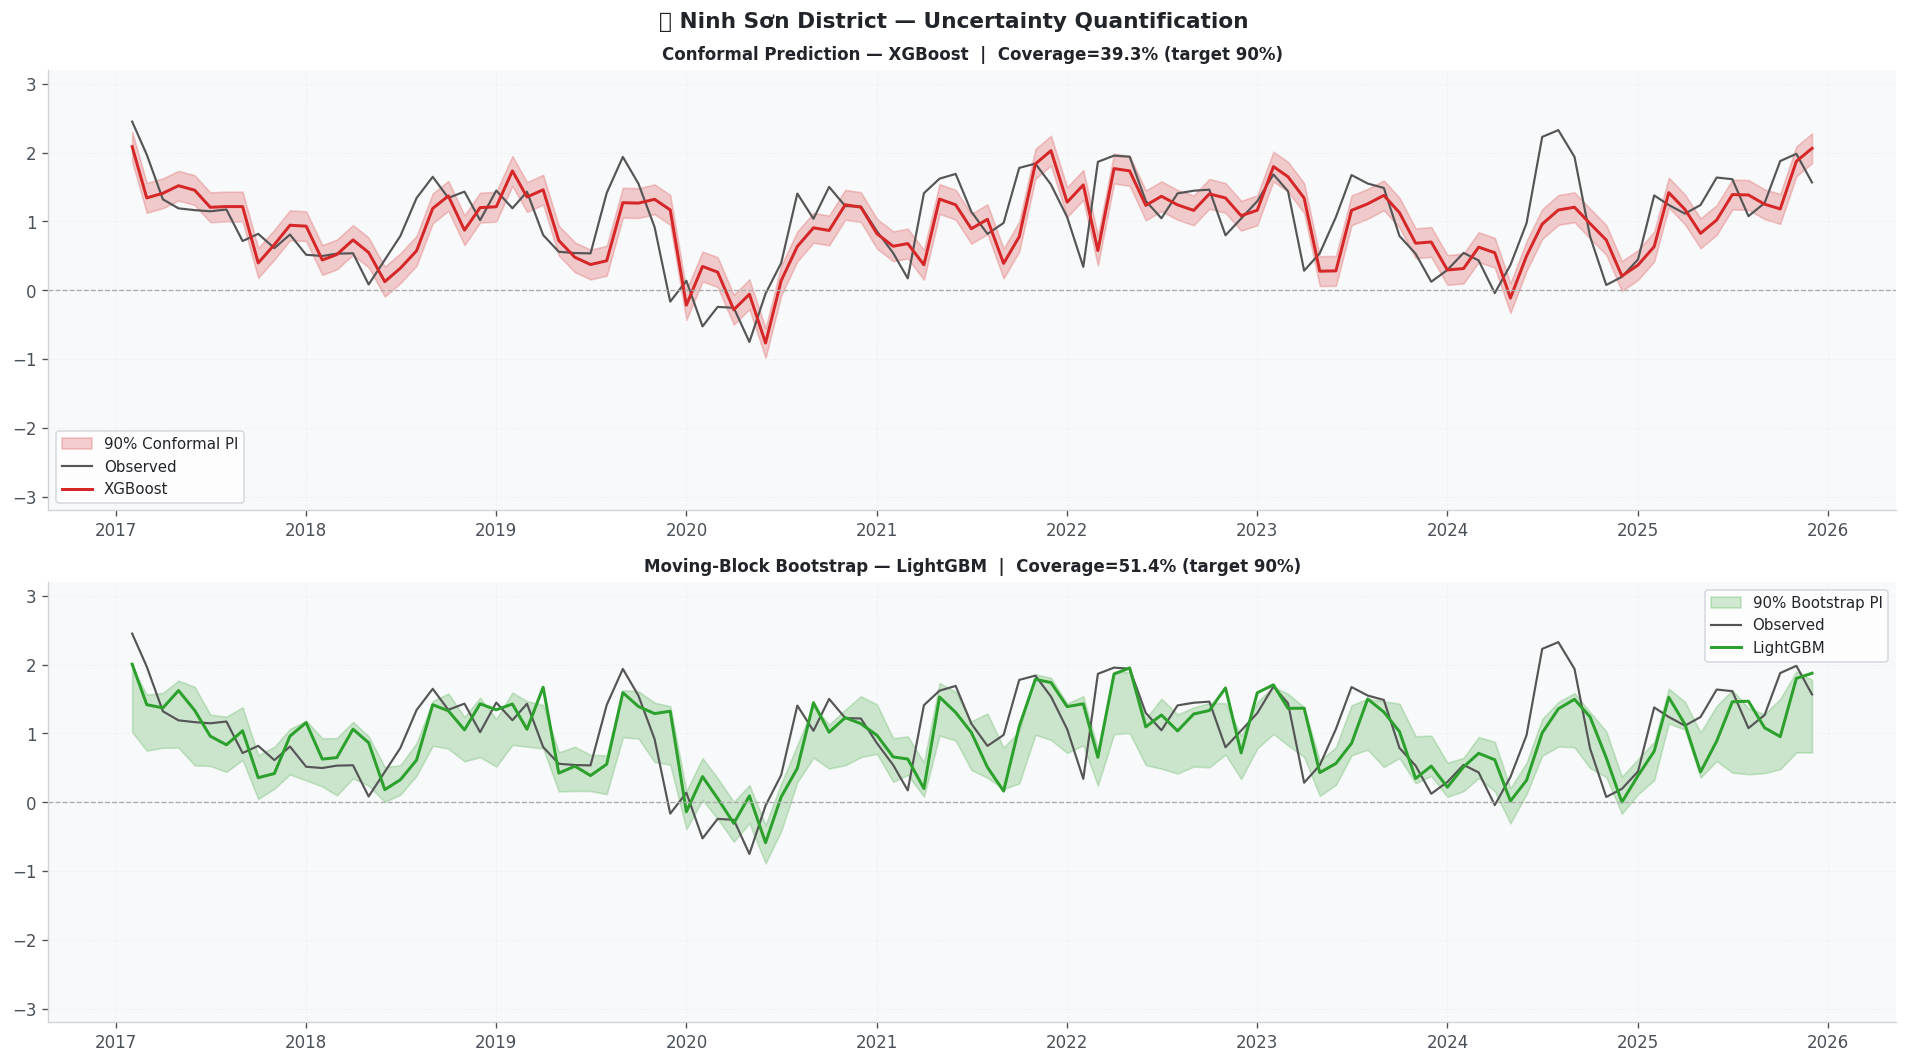

✅ Saved fig_08_uncertainty_Ninh_Sơn_District.png


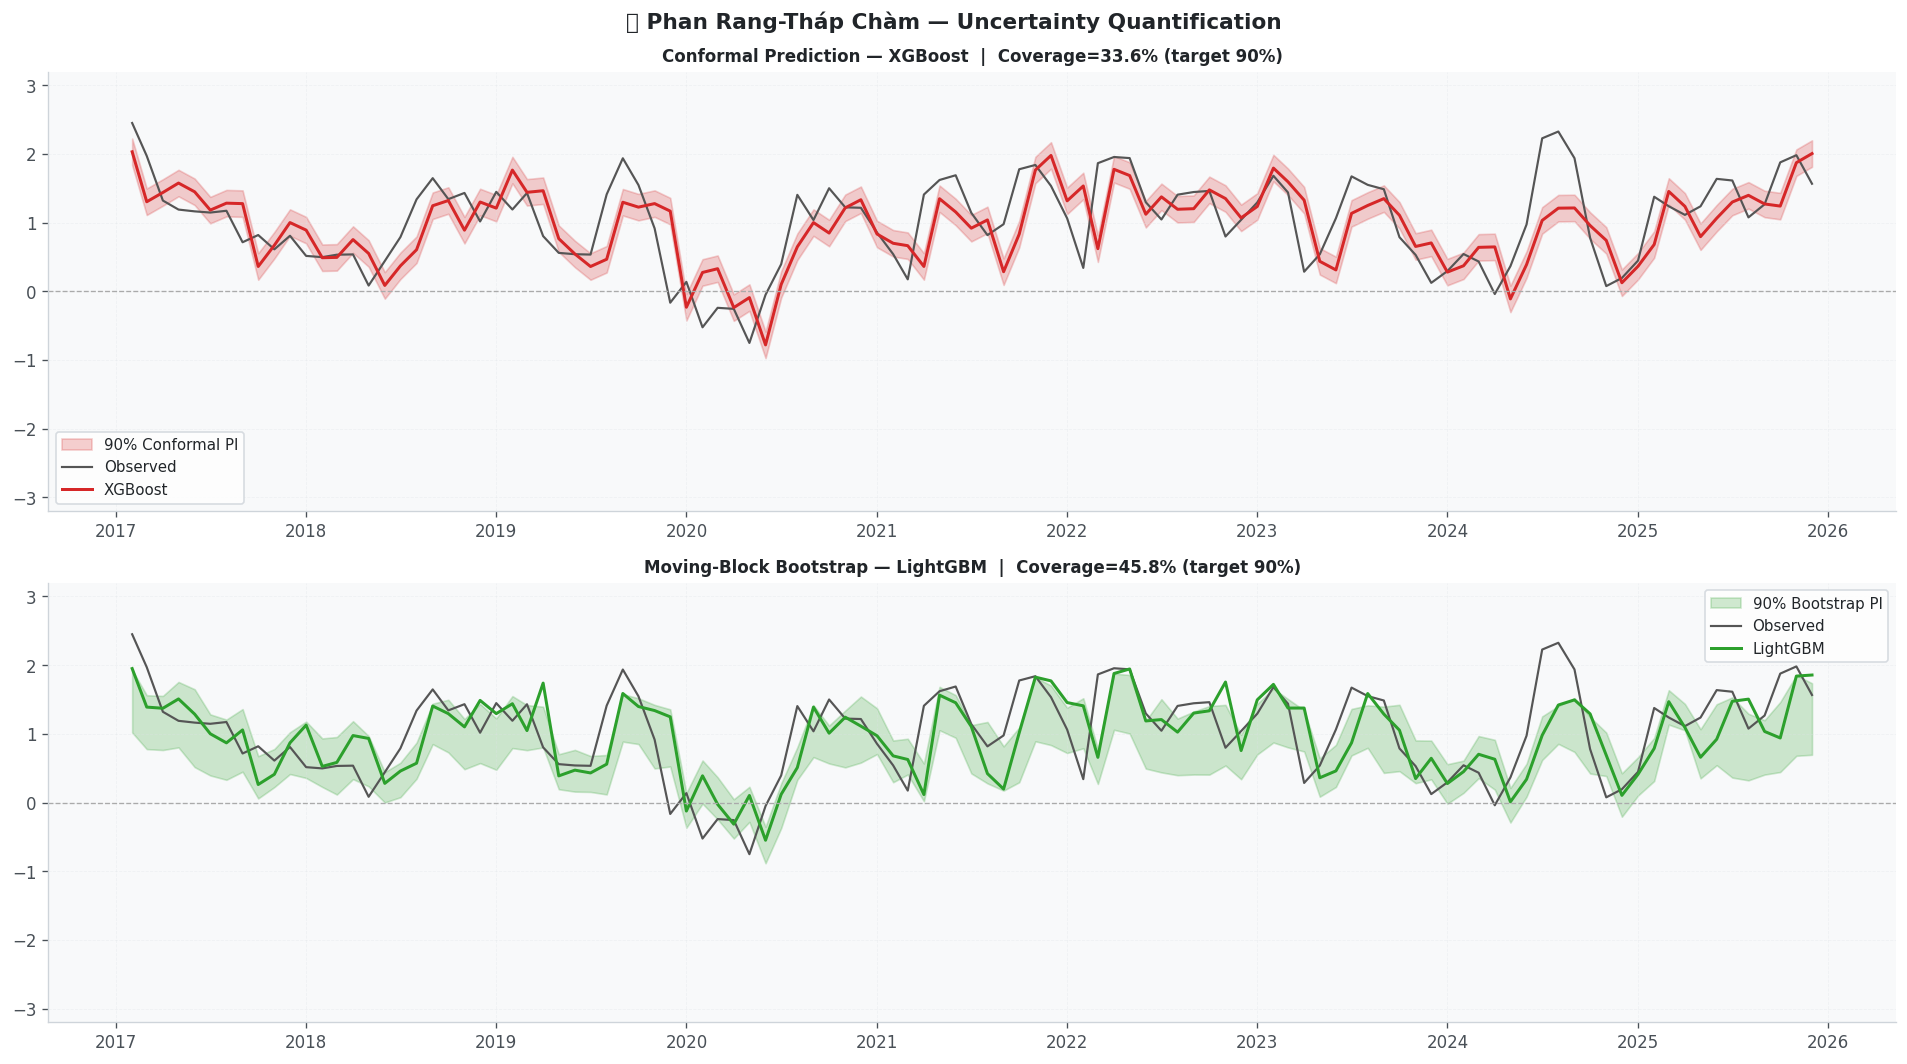

✅ Saved fig_08_uncertainty_Phan_Rang-Tháp_Chàm.png


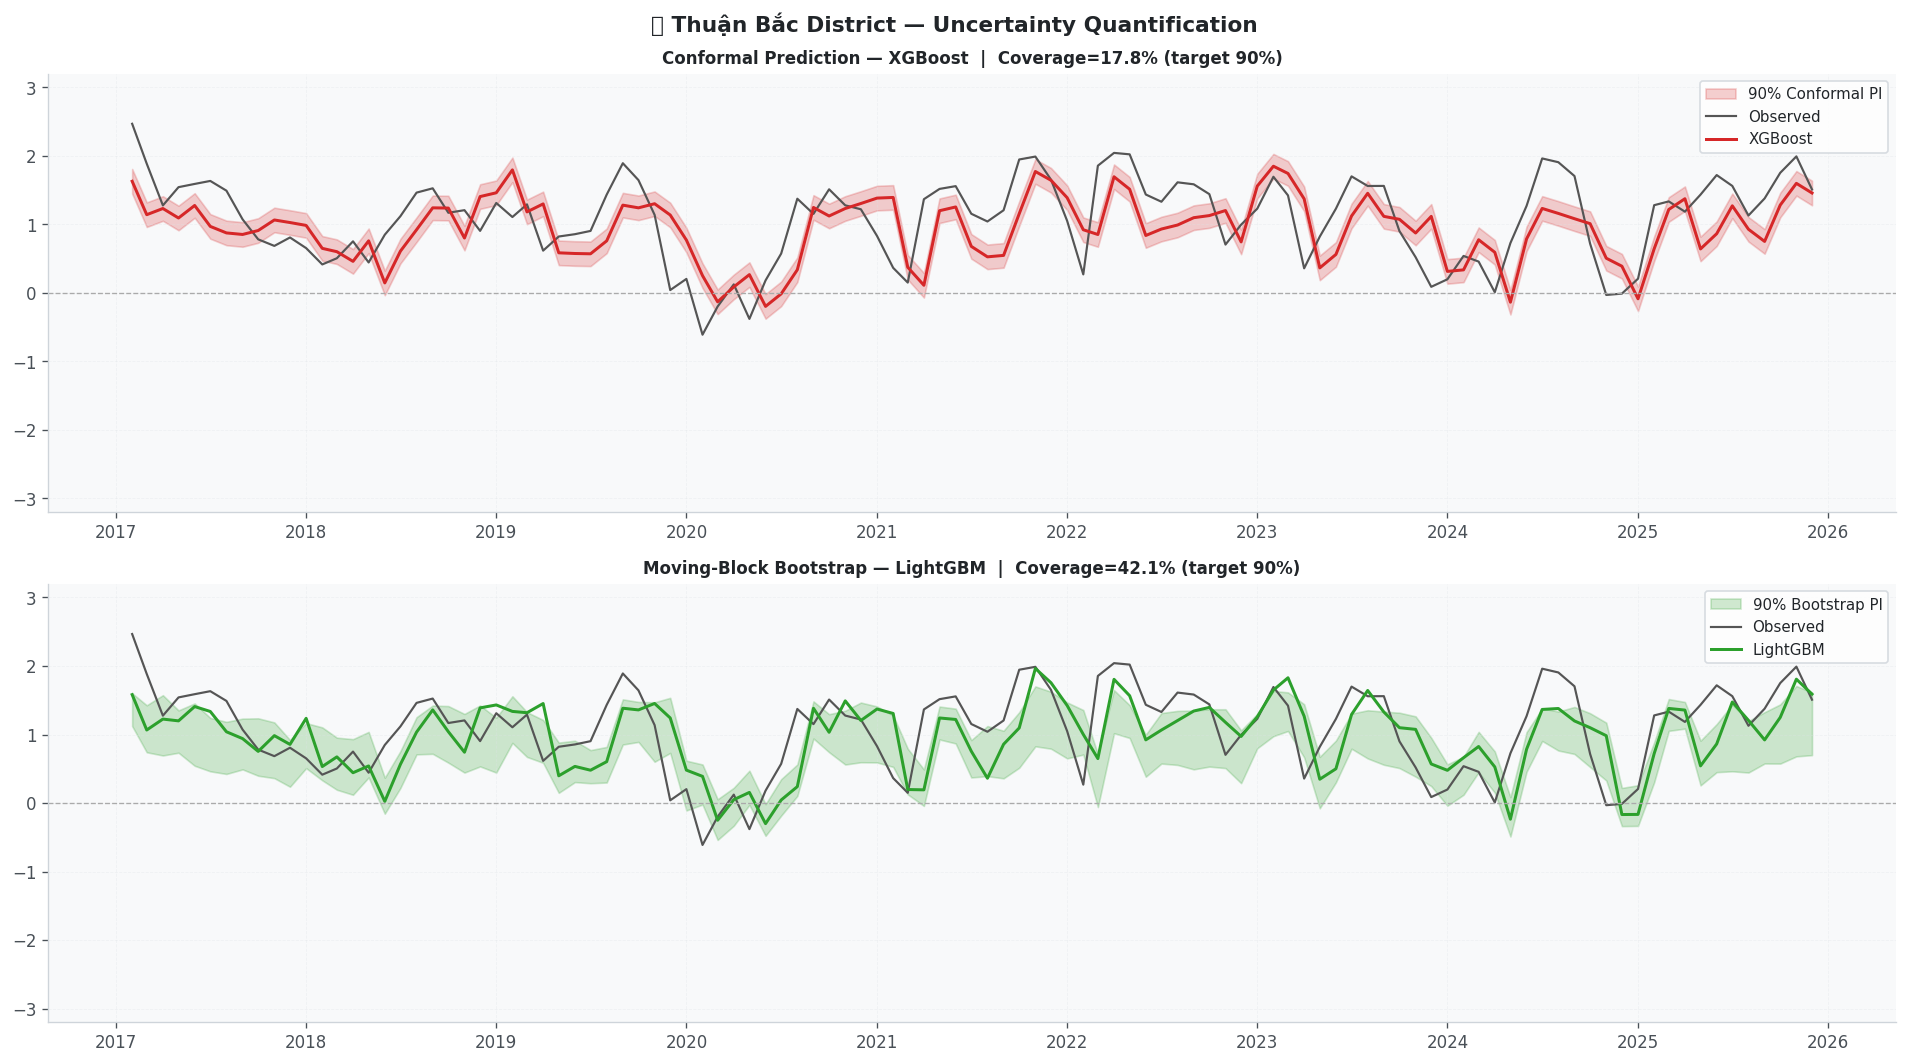

✅ Saved fig_08_uncertainty_Thuận_Bắc_District.png


In [15]:
# Cell 16 — Uncertainty band visualizations (light theme)
for loc in LOCATIONS:
    y_te = splits[loc]["y_te"]
    idx  = splits[loc]["idx_te"]

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), facecolor="white")

    # Conformal — XGBoost
    ax = axes[0]
    mname = "XGBoost"
    unc   = unc_results[loc]["Conformal"][mname]
    pred  = results[loc][mname]["pred"]
    n     = min(len(idx), len(pred))
    ax.fill_between(idx[:n], unc["lower"][:n], unc["upper"][:n],
                    alpha=0.22, color="#d62728", label="90% Conformal PI")
    ax.plot(idx[:n], y_te[:n], color="#555555", lw=1.3, label="Observed")
    ax.plot(idx[:n], pred[:n], color="#d62728", lw=1.8, label=mname)
    ax.axhline(0, color="#aaaaaa", lw=0.8, ls="--")
    ax.set_title(f"Conformal Prediction — {mname}  |  "
                 f"Coverage={unc['coverage']*100:.1f}% (target 90%)", fontsize=10)
    ax.set_ylim(-3.2, 3.2); ax.legend(fontsize=9); ax.grid(True, alpha=0.35)
    ax.spines[["top","right"]].set_visible(False)

    # Bootstrap — LightGBM
    ax = axes[1]
    mname = "LightGBM"
    unc   = unc_results[loc]["Bootstrap"][mname]
    pred  = results[loc][mname]["pred"]
    n     = min(len(idx), len(pred))
    ax.fill_between(idx[:n], unc["lower"][:n], unc["upper"][:n],
                    alpha=0.22, color="#2ca02c", label="90% Bootstrap PI")
    ax.plot(idx[:n], y_te[:n], color="#555555", lw=1.3, label="Observed")
    ax.plot(idx[:n], pred[:n], color="#2ca02c", lw=1.8, label=mname)
    ax.axhline(0, color="#aaaaaa", lw=0.8, ls="--")
    ax.set_title(f"Moving-Block Bootstrap — {mname}  |  "
                 f"Coverage={unc['coverage']*100:.1f}% (target 90%)", fontsize=10)
    ax.set_ylim(-3.2, 3.2); ax.legend(fontsize=9); ax.grid(True, alpha=0.35)
    ax.spines[["top","right"]].set_visible(False)

    plt.suptitle(f"📍 {loc} — Uncertainty Quantification", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = f"fig_08_uncertainty_{loc.replace(' ', '_')}.png"
    plt.savefig(fname, **SAVEFIG_KW)
    plt.show()
    print(f"✅ Saved {fname}")


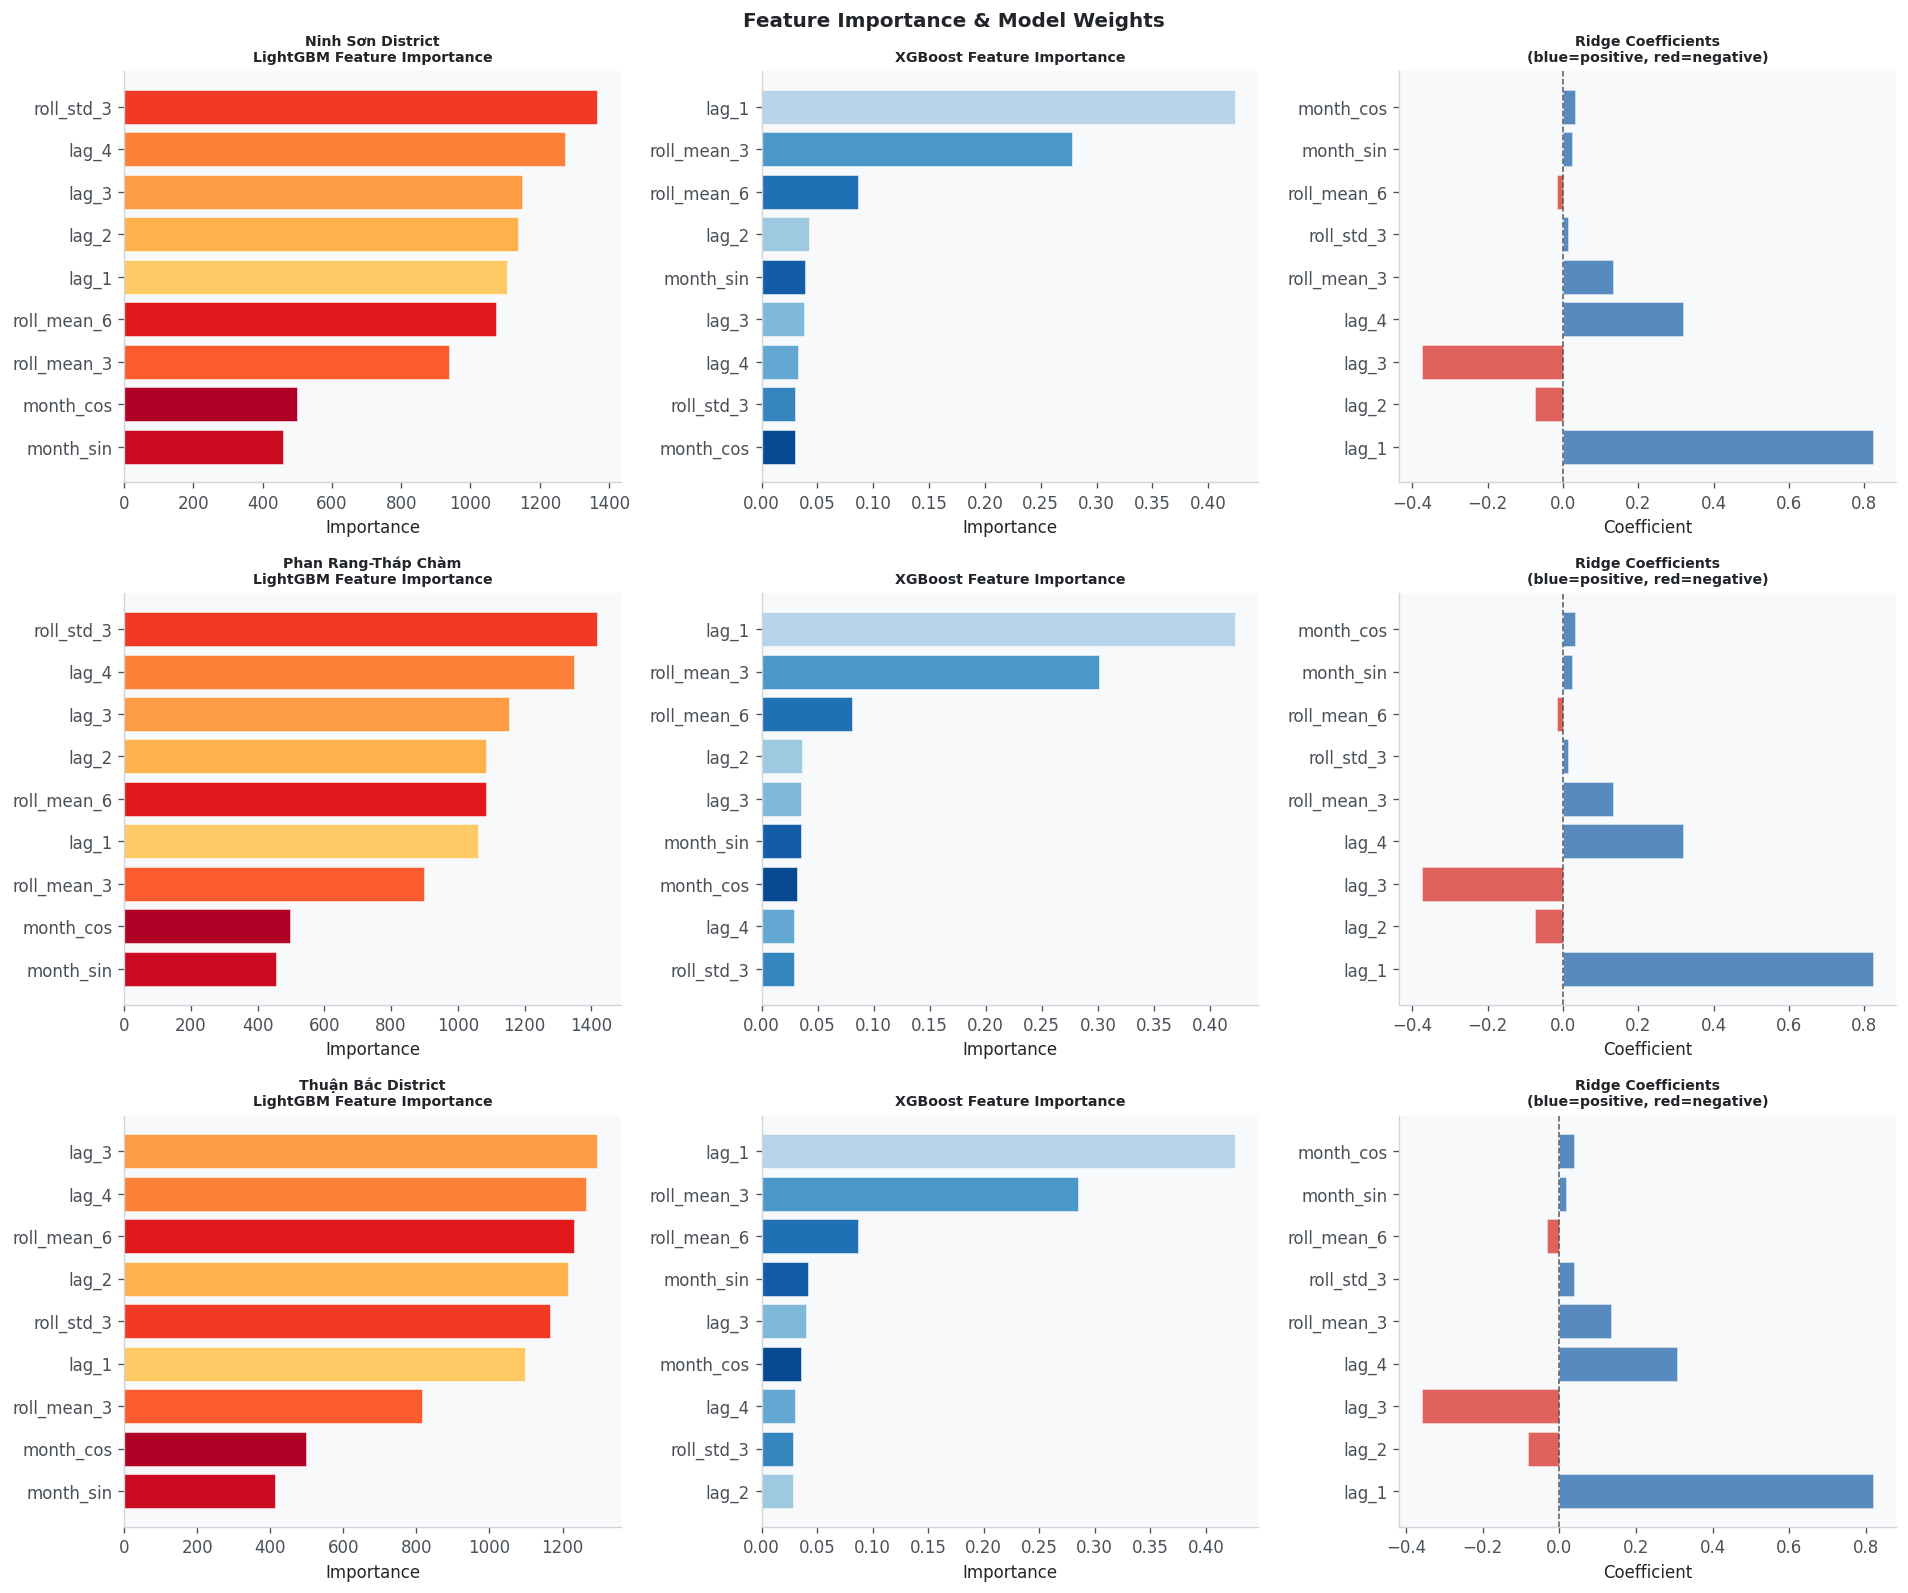

✅ Figure 9 saved


In [16]:
# Cell 17 — Feature importance (LightGBM & XGBoost) + Ridge coefficients (light theme)
fig, axes = plt.subplots(len(LOCATIONS), 3,
                         figsize=(16, 4.5 * len(LOCATIONS)),
                         facecolor="white")
if len(LOCATIONS) == 1:
    axes = axes.reshape(1, -1)

for i, loc in enumerate(LOCATIONS):
    # LightGBM
    ax = axes[i, 0]
    imp = models_fit[loc]["LightGBM"].feature_importances_
    order = np.argsort(imp)
    colors_imp = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(imp)))
    ax.barh(np.array(FEAT_COLS)[order], imp[order],
            color=colors_imp[order], edgecolor="white", lw=0.3)
    ax.set_title(f"{loc[:20]}\nLightGBM Feature Importance", fontsize=8.5)
    ax.set_xlabel("Importance")
    ax.spines[["top","right"]].set_visible(False)

    # XGBoost
    ax = axes[i, 1]
    imp = models_fit[loc]["XGBoost"].feature_importances_
    order = np.argsort(imp)
    colors_imp2 = plt.cm.Blues(np.linspace(0.3, 0.9, len(imp)))
    ax.barh(np.array(FEAT_COLS)[order], imp[order],
            color=colors_imp2[order], edgecolor="white", lw=0.3)
    ax.set_title("XGBoost Feature Importance", fontsize=8.5)
    ax.set_xlabel("Importance")
    ax.spines[["top","right"]].set_visible(False)

    # Ridge coefficients
    ax = axes[i, 2]
    coef = models_fit[loc]["Ridge"].coef_
    colors_coef = ["#2166ac" if c >= 0 else "#d73027" for c in coef]
    ax.barh(FEAT_COLS, coef, color=colors_coef, alpha=0.75, edgecolor="white", lw=0.3)
    ax.axvline(0, color="#555555", lw=0.9, ls="--")
    ax.set_title("Ridge Coefficients\n(blue=positive, red=negative)", fontsize=8.5)
    ax.set_xlabel("Coefficient")
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Feature Importance & Model Weights", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_09_feature_importance.png", **SAVEFIG_KW)
plt.show()
print("✅ Figure 9 saved")


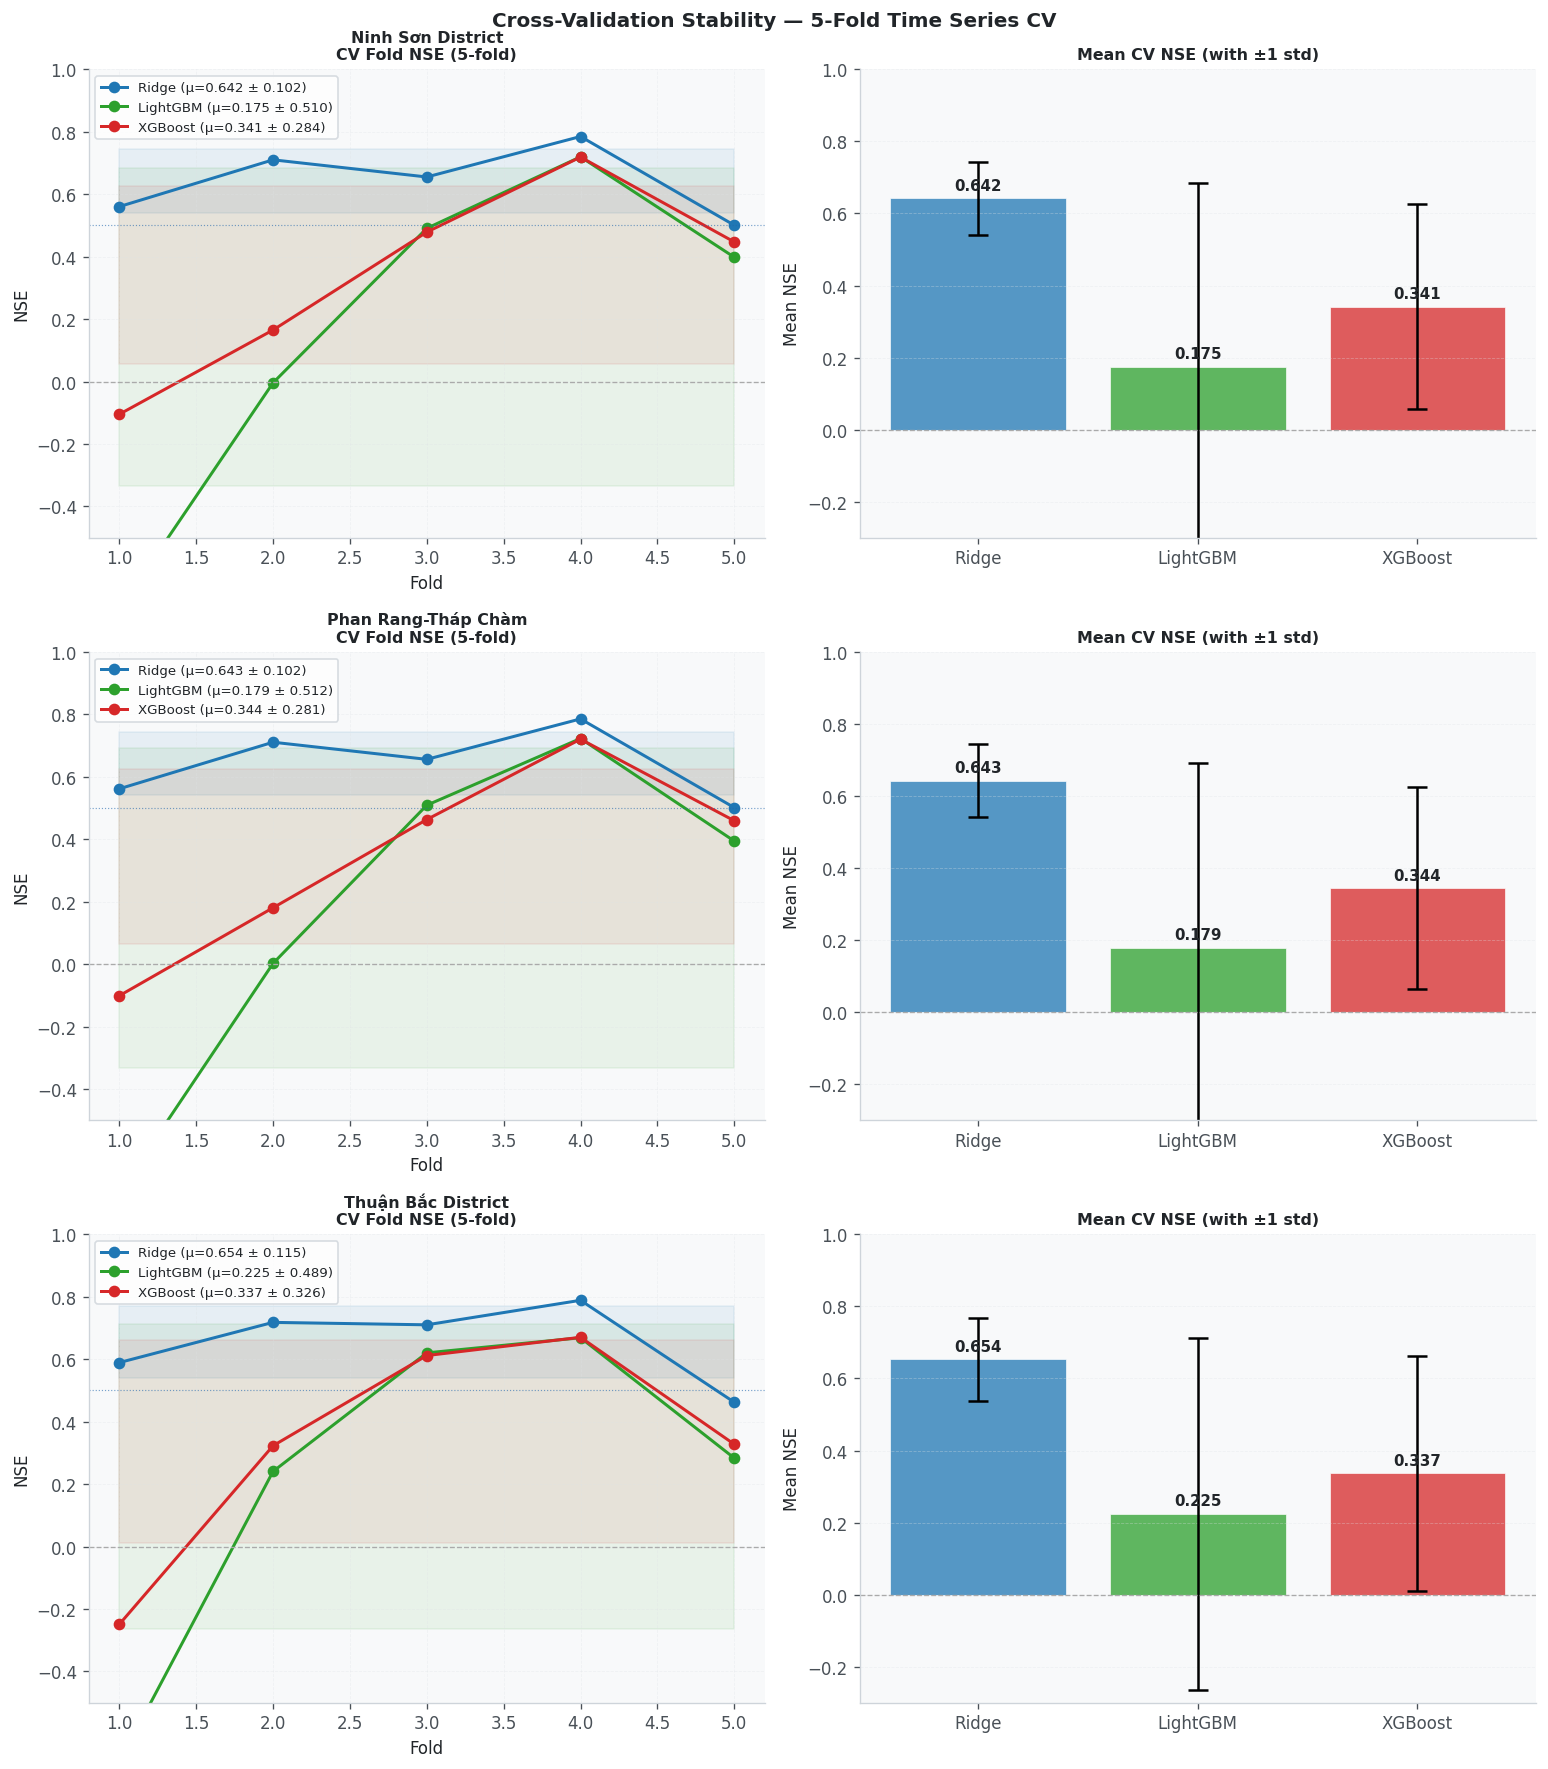


── CV Mean NSE ──

  Ninh Sơn District
    Ridge         mean=0.642  std=0.102
    LightGBM      mean=0.175  std=0.510
    XGBoost       mean=0.341  std=0.284

  Phan Rang-Tháp Chàm
    Ridge         mean=0.643  std=0.102
    LightGBM      mean=0.179  std=0.512
    XGBoost       mean=0.344  std=0.281

  Thuận Bắc District
    Ridge         mean=0.654  std=0.115
    LightGBM      mean=0.225  std=0.489
    XGBoost       mean=0.337  std=0.326

✅ Cross-validation complete


In [17]:
# Cell 18 — Time-Series Cross-Validation (5-fold) + bar summary (light theme)
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

cv_scores = {loc: {m: [] for m in ["Ridge","LightGBM","XGBoost"]} for loc in LOCATIONS}

for loc in LOCATIONS:
    df_f   = feat_sets[loc]
    X_full = df_f[FEAT_COLS].values
    y_full = df_f["spei"].values

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_full)):
        X_tr_, X_va_ = X_full[tr_idx], X_full[va_idx]
        y_tr_, y_va_ = y_full[tr_idx], y_full[va_idx]
        sc_f = StandardScaler()
        X_tr_s_ = sc_f.fit_transform(X_tr_)
        X_va_s_ = sc_f.transform(X_va_)

        for mname, Mdl, kwargs in [
            ("Ridge",    Ridge,             {"alpha": 1.0}),
            ("LightGBM", lgb.LGBMRegressor, {"n_estimators":200,"learning_rate":0.05,
                                             "num_leaves":31,"random_state":42,"verbose":-1}),
            ("XGBoost",  xgb.XGBRegressor,  {"n_estimators":200,"learning_rate":0.05,
                                             "max_depth":4,"random_state":42,"verbosity":0})]:
            m = Mdl(**kwargs)
            m.fit(X_tr_s_, y_tr_)
            cv_scores[loc][mname].append(nse(y_va_, m.predict(X_va_s_)))

# ── Plot: fold lines + mean bar summary ─────────────────────────────────────
n_locs = len(LOCATIONS)
fig, axes = plt.subplots(n_locs, 2, figsize=(13, 5 * n_locs), facecolor="white")
if n_locs == 1:
    axes = axes.reshape(1, -1)

for row, loc in enumerate(LOCATIONS):
    # Line plot per fold
    ax1 = axes[row, 0]
    for mname, col in zip(["Ridge","LightGBM","XGBoost"], PAL):
        scores = cv_scores[loc][mname]
        ax1.plot(range(1, N_SPLITS+1), scores, "o-", color=col, lw=1.8, ms=6,
                 label=f"{mname} (μ={np.mean(scores):.3f} ± {np.std(scores):.3f})")
        ax1.fill_between(range(1, N_SPLITS+1),
                         [np.mean(scores) - np.std(scores)] * N_SPLITS,
                         [np.mean(scores) + np.std(scores)] * N_SPLITS,
                         color=col, alpha=0.08)
    ax1.axhline(0, color="#aaaaaa", lw=0.8, ls="--")
    ax1.axhline(0.5, color="#2166ac", lw=0.7, ls=":", alpha=0.6)
    ax1.set_xlabel("Fold"); ax1.set_ylabel("NSE")
    ax1.set_title(f"{loc}\nCV Fold NSE (5-fold)", fontsize=9.5)
    ax1.legend(fontsize=8); ax1.grid(True, alpha=0.35); ax1.set_ylim(-0.5, 1.0)
    ax1.spines[["top","right"]].set_visible(False)

    # Bar summary: mean ± std
    ax2 = axes[row, 1]
    names  = ["Ridge","LightGBM","XGBoost"]
    means  = [np.mean(cv_scores[loc][m]) for m in names]
    stds   = [np.std(cv_scores[loc][m])  for m in names]
    bars   = ax2.bar(names, means, yerr=stds, color=PAL[:3], alpha=0.75,
                     capsize=6, error_kw=dict(lw=1.5, capthick=1.5),
                     edgecolor="white", linewidth=0.5)
    for bar, mu in zip(bars, means):
        ax2.text(bar.get_x() + bar.get_width()/2, mu + 0.015,
                 f"{mu:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax2.axhline(0, color="#aaaaaa", lw=0.8, ls="--")
    ax2.set_ylabel("Mean NSE"); ax2.set_ylim(-0.3, 1.0)
    ax2.set_title("Mean CV NSE (with ±1 std)", fontsize=9.5)
    ax2.grid(axis="y", alpha=0.35)
    ax2.spines[["top","right"]].set_visible(False)

plt.suptitle("Cross-Validation Stability — 5-Fold Time Series CV",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_10_crossval.png", **SAVEFIG_KW)
plt.show()

print("\n── CV Mean NSE ──")
for loc in LOCATIONS:
    print(f"\n  {loc}")
    for mname in ["Ridge","LightGBM","XGBoost"]:
        scores = cv_scores[loc][mname]
        print(f"    {mname:12s}  mean={np.mean(scores):.3f}  std={np.std(scores):.3f}")
print("\n✅ Cross-validation complete")



🔮 Forecasting Ninh Sơn District ...


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


   Weights Ridge=0.345  LightGBM=0.331  SARIMA=0.323
   Conformal q̂=0.687

🔮 Forecasting Phan Rang-Tháp Chàm ...


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


   Weights Ridge=0.345  LightGBM=0.331  SARIMA=0.323
   Conformal q̂=0.687

🔮 Forecasting Thuận Bắc District ...


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


   Weights Ridge=0.341  LightGBM=0.327  SARIMA=0.332
   Conformal q̂=0.714

✅ All 2026–2030 forecasts generated

📄 CSV saved → SPEI3_Monthly_Forecast_2026_2030.csv  (180 rows)


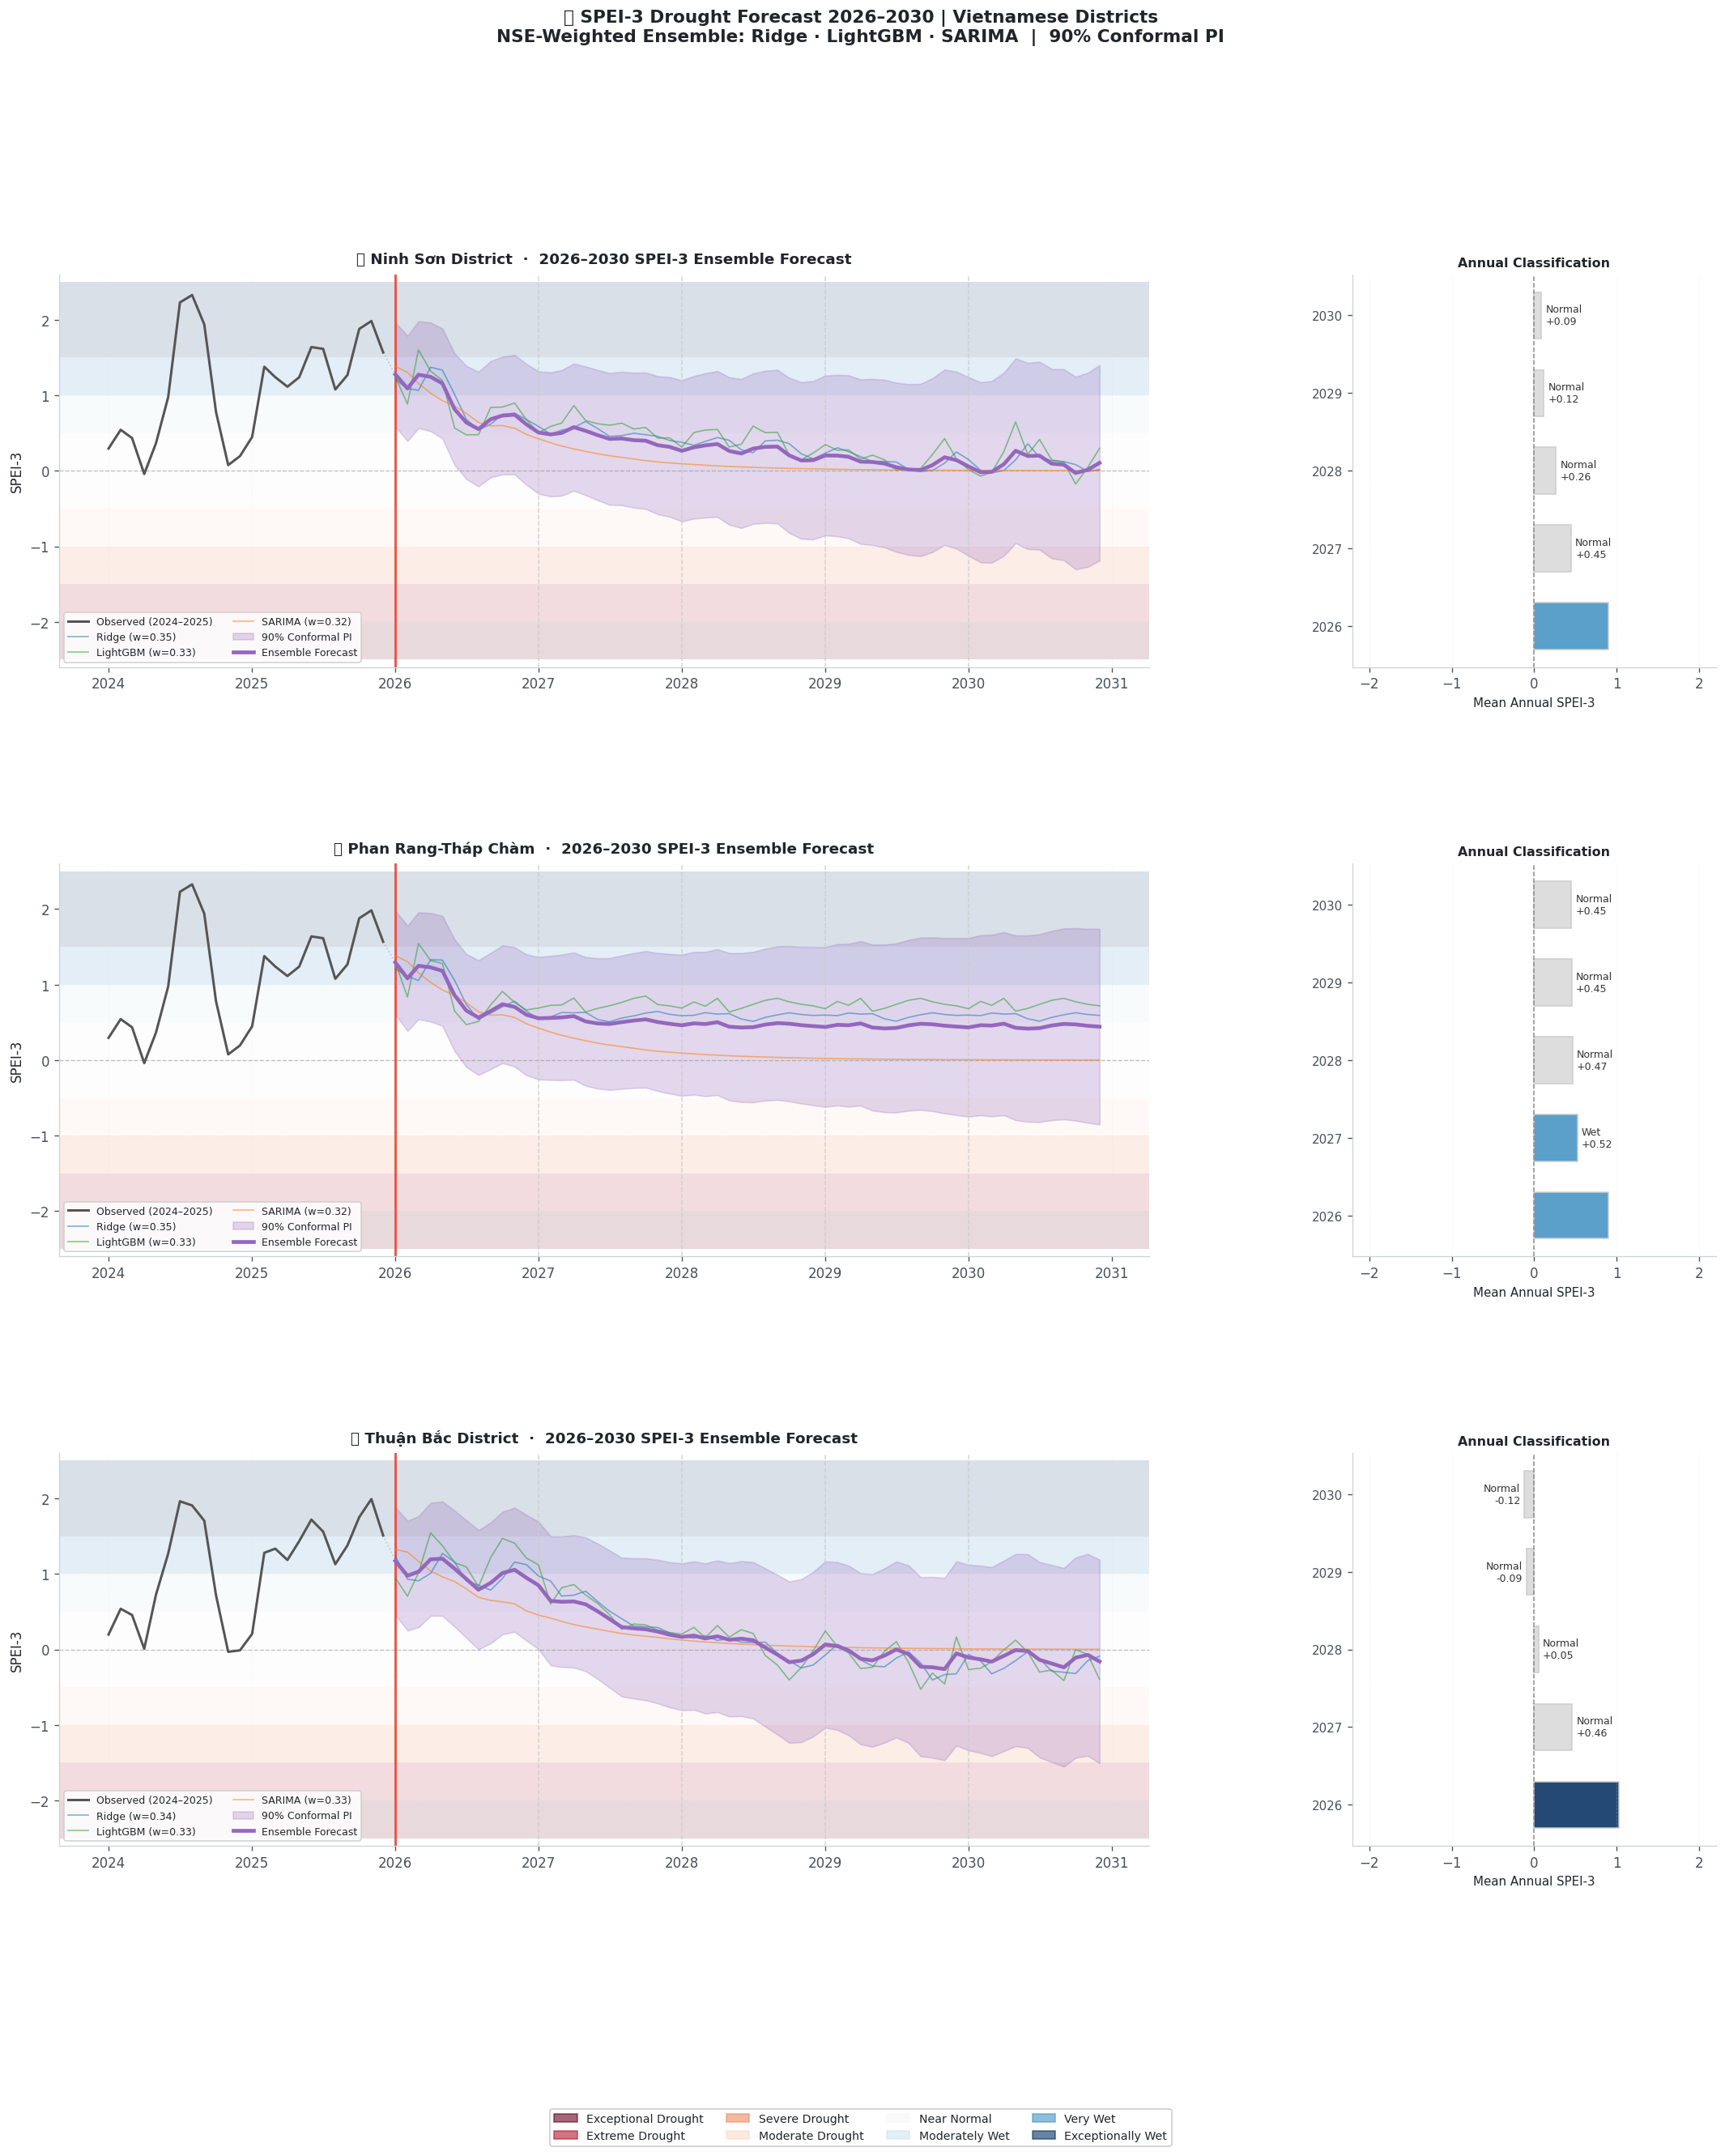


✅ Figure 19 — 2026–2030 Forecast saved (light theme)

══════════════════════════════════════════════════════════════════════
  2026–2030 FORECAST SUMMARY  (NSE-Weighted Ensemble)
══════════════════════════════════════════════════════════════════════

  📍 Ninh Sơn District
     Weights Ridge=0.345  LightGBM=0.331  SARIMA=0.323
     Year     Mean SPEI      Min      Max  Drought Months  Class
     ─────────────────────────────────────────────────────────────────
       2026       0.901    0.551    1.275               0  🔵 Wet
       2027       0.447    0.317    0.577               0  🟢 Normal
       2028       0.263    0.136    0.354               0  🟢 Normal
       2029       0.115    0.009    0.203               0  🟢 Normal
       2030       0.086   -0.030    0.265               0  🟢 Normal

  📍 Phan Rang-Tháp Chàm
     Weights Ridge=0.345  LightGBM=0.331  SARIMA=0.323
     Year     Mean SPEI      Min      Max  Drought Months  Class
     ────────────────────────────────────────────────

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download triggered


In [18]:
# Cell 19 — 2026–2030 Future Forecast + Visualisation
import calendar

MODEL_NSE_REF = {
    "Ninh Sơn District":         {"Ridge": 0.505, "LightGBM": 0.464, "SARIMA": 0.440},
    "Phan Rang-Tháp Chàm":       {"Ridge": 0.505, "LightGBM": 0.464, "SARIMA": 0.440},
    "Thuận Bắc District":        {"Ridge": 0.475, "LightGBM": 0.433, "SARIMA": 0.446},
}

def softmax_weights(nse_dict):
    vals = np.array(list(nse_dict.values())); vals = np.clip(vals, 0, None)
    exp  = np.exp(vals - vals.max())
    return dict(zip(nse_dict.keys(), exp / exp.sum()))

def spei_category(v):
    if   v <= -2.0: return "Exceptional Drought"
    elif v <= -1.5: return "Extreme Drought"
    elif v <= -1.0: return "Severe Drought"
    elif v <= -0.5: return "Moderate Drought"
    elif v <   0.5: return "Near Normal"
    elif v <   1.0: return "Moderately Wet"
    elif v <   1.5: return "Very Wet"
    else:           return "Exceptionally Wet"

FORECAST_START = pd.Timestamp("2026-01-01")
FORECAST_END   = pd.Timestamp("2030-12-01")
future_idx     = pd.date_range(FORECAST_START, FORECAST_END, freq="MS")
N_STEPS        = len(future_idx)

future_forecasts  = {}
all_monthly_rows  = []

for loc in LOCATIONS:
    print(f"\n🔮 Forecasting {loc} ...")
    df_f     = feat_sets[loc]
    X_full   = df_f[FEAT_COLS].values
    y_full   = df_f["spei"].values
    raw_full = df_raw[df_raw.Location == loc].set_index("Month_Date")["SPEI_3_PM"]

    sc_full  = StandardScaler(); X_full_s = sc_full.fit_transform(X_full)
    ridge_f  = Ridge(alpha=1.0); ridge_f.fit(X_full_s, y_full)
    lgbm_f   = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                  num_leaves=31, min_child_samples=10,
                                  random_state=42, verbose=-1)
    lgbm_f.fit(X_full_s, y_full)
    sarima_f    = SARIMAX(raw_full, order=(1,0,1), seasonal_order=(1,0,1,12),
                          enforce_stationarity=False, enforce_invertibility=False)
    sarima_fit_f = sarima_f.fit(disp=False)

    n_cal   = int(len(y_full) * 0.20)
    cal_res = np.abs(y_full[-n_cal:] - ridge_f.predict(X_full_s[-n_cal:]))
    q_hat   = np.quantile(cal_res, 0.90)

    history     = list(raw_full.values[-6:])
    ridge_preds = []; lgbm_preds = []
    for step in range(N_STEPS):
        month = future_idx[step].month
        lag1,lag2,lag3,lag4 = history[-1],history[-2],history[-3],history[-4]
        rm3 = np.mean(history[-3:]); rs3 = np.std(history[-3:]) if len(history)>=3 else 0.0
        rm6 = np.mean(history[-6:]) if len(history)>=6 else np.mean(history)
        feat_vec   = np.array([[lag1,lag2,lag3,lag4,rm3,rs3,rm6,
                                np.sin(2*np.pi*month/12), np.cos(2*np.pi*month/12)]])
        feat_vec_s = sc_full.transform(feat_vec)
        r_pred = ridge_f.predict(feat_vec_s)[0]
        l_pred = lgbm_f.predict(feat_vec_s)[0]
        ridge_preds.append(r_pred); lgbm_preds.append(l_pred)
        nse_r = MODEL_NSE_REF.get(loc, {}).get("Ridge",    0.48)
        nse_l = MODEL_NSE_REF.get(loc, {}).get("LightGBM", 0.45)
        w_r = nse_r / (nse_r + nse_l)
        history.append(float(w_r * r_pred + (1-w_r) * l_pred))

    ridge_preds = np.clip(np.array(ridge_preds), -2.5, 2.5)
    lgbm_preds  = np.clip(np.array(lgbm_preds),  -2.5, 2.5)
    sarima_arr  = np.clip(sarima_fit_f.forecast(steps=N_STEPS).values, -2.5, 2.5)

    nse_ref = MODEL_NSE_REF.get(loc, {
        "Ridge":    results[loc]["Ridge"]["metrics"]["NSE"],
        "LightGBM": results[loc]["LightGBM"]["metrics"]["NSE"],
        "SARIMA":   results[loc]["SARIMA"]["metrics"]["NSE"]})
    w = softmax_weights(nse_ref)
    ens = np.clip(w["Ridge"]*ridge_preds + w["LightGBM"]*lgbm_preds + w["SARIMA"]*sarima_arr,
                  -2.5, 2.5)
    step_factor = 1.0 + 0.015 * np.arange(N_STEPS)
    lower = np.clip(ens - q_hat * step_factor, -2.5, 2.5)
    upper = np.clip(ens + q_hat * step_factor, -2.5, 2.5)

    future_forecasts[loc] = {
        "ensemble": pd.Series(ens,         index=future_idx, name="Ensemble"),
        "lower":    pd.Series(lower,       index=future_idx, name="Lower90"),
        "upper":    pd.Series(upper,       index=future_idx, name="Upper90"),
        "ridge":    pd.Series(ridge_preds, index=future_idx, name="Ridge"),
        "lgbm":     pd.Series(lgbm_preds,  index=future_idx, name="LightGBM"),
        "sarima":   pd.Series(sarima_arr,  index=future_idx, name="SARIMA"),
        "weights":  w,
    }
    print(f"   Weights Ridge={w['Ridge']:.3f}  LightGBM={w['LightGBM']:.3f}  SARIMA={w['SARIMA']:.3f}")
    print(f"   Conformal q̂={q_hat:.3f}")

    for i, dt in enumerate(future_idx):
        all_monthly_rows.append({
            "Location": loc, "Year": dt.year, "Month": dt.month,
            "Month_Name": dt.strftime("%B"), "Date": dt.strftime("%Y-%m-%d"),
            "SPEI3_Ridge":    round(float(ridge_preds[i]), 6),
            "SPEI3_LightGBM": round(float(lgbm_preds[i]),  6),
            "SPEI3_SARIMA":   round(float(sarima_arr[i]),   6),
            "SPEI3_Ensemble": round(float(ens[i]),          6),
            "PI_Lower_90":    round(float(lower[i]),        6),
            "PI_Upper_90":    round(float(upper[i]),        6),
            "SPEI_Category":  spei_category(float(ens[i])),
            "Ensemble_Weights": f"Ridge={w['Ridge']:.3f}|LightGBM={w['LightGBM']:.3f}|SARIMA={w['SARIMA']:.3f}",
        })

print("\n✅ All 2026–2030 forecasts generated")

# ── Save CSV ─────────────────────────────────────────────────────────────────
CSV_PATH = "SPEI3_Monthly_Forecast_2026_2030.csv"
df_forecast = pd.DataFrame(all_monthly_rows)
df_forecast.sort_values(["Location","Year","Month"], inplace=True)
df_forecast.reset_index(drop=True, inplace=True)
df_forecast.to_csv(CSV_PATH, index=False, encoding="utf-8-sig")
print(f"\n📄 CSV saved → {CSV_PATH}  ({len(df_forecast)} rows)")

# ═══════════════════════════════════════════════════════════════════════════
# ADVANCED LIGHT-THEME FORECAST VISUALISATION
# ═══════════════════════════════════════════════════════════════════════════

# SPEI category bands — light-friendly palette
SPEI_CATS = [
    (-2.5, -2.0, "#67001f", "Exceptional Drought"),
    (-2.0, -1.5, "#b2182b", "Extreme Drought"),
    (-1.5, -1.0, "#ef8a62", "Severe Drought"),
    (-1.0, -0.5, "#fddbc7", "Moderate Drought"),
    (-0.5,  0.5, "#f7f7f7", "Near Normal"),
    ( 0.5,  1.0, "#d1e5f0", "Moderately Wet"),
    ( 1.0,  1.5, "#4393c3", "Very Wet"),
    ( 1.5,  2.5, "#053061", "Exceptionally Wet"),
]

def add_spei_shading(ax):
    for lo, hi, col, _ in SPEI_CATS:
        ax.axhspan(lo, hi, color=col, alpha=0.15, linewidth=0)

n_locs = len(LOCATIONS)
fig    = plt.figure(figsize=(22, 7 * n_locs), facecolor="white")
gs     = gridspec.GridSpec(n_locs, 2, width_ratios=[3, 1], hspace=0.5, wspace=0.28)

for row, loc in enumerate(LOCATIONS):
    fc  = future_forecasts[loc]
    ens = fc["ensemble"]; lo = fc["lower"]; hi = fc["upper"]
    idx = ens.index

    ax_main = fig.add_subplot(gs[row, 0])
    ax_main.set_facecolor("white")
    add_spei_shading(ax_main)

    # Historical context (last 24 months)
    ctx      = df_raw[df_raw.Location == loc].set_index("Month_Date")["SPEI_3_PM"]
    ctx_plot = ctx.iloc[-24:]
    ax_main.plot(ctx_plot.index, ctx_plot.values,
                 color="#555555", lw=1.8, label="Observed (2024–2025)", zorder=3)
    ax_main.plot([ctx_plot.index[-1], idx[0]], [ctx_plot.values[-1], ens.iloc[0]],
                 color="#aaaaaa", lw=1, ls=":", alpha=0.6)

    # Individual model traces
    ax_main.plot(idx, fc["ridge"],  color="#1f77b4", lw=1.0, alpha=0.55,
                 label=f"Ridge (w={fc['weights']['Ridge']:.2f})", zorder=4)
    ax_main.plot(idx, fc["lgbm"],   color="#2ca02c", lw=1.0, alpha=0.55,
                 label=f"LightGBM (w={fc['weights']['LightGBM']:.2f})", zorder=4)
    ax_main.plot(idx, fc["sarima"], color="#ff7f0e", lw=1.0, alpha=0.55,
                 label=f"SARIMA (w={fc['weights']['SARIMA']:.2f})", zorder=4)

    # Uncertainty band + ensemble
    ax_main.fill_between(idx, lo, hi, alpha=0.25, color="#9467bd",
                         label="90% Conformal PI", zorder=2)
    ax_main.plot(idx, ens, color="#9467bd", lw=2.8,
                 label="Ensemble Forecast", zorder=5)

    # Year markers
    for yr in range(2026, 2031):
        ax_main.axvline(pd.Timestamp(f"{yr}-01-01"), color="#cccccc", lw=0.9, ls="--", alpha=0.8)
    ax_main.axvline(pd.Timestamp("2026-01-01"), color="#e74c3c", lw=1.8, ls="-", alpha=0.9)
    ax_main.axhline(0, color="#888888", lw=0.8, ls="--", alpha=0.5)

    ax_main.set_ylim(-2.6, 2.6)
    ax_main.set_ylabel("SPEI-3", fontsize=10)
    ax_main.set_title(f"📍 {loc}  ·  2026–2030 SPEI-3 Ensemble Forecast", fontsize=11, pad=8)
    ax_main.legend(fontsize=7.5, loc="lower left", ncol=2,
                   framealpha=0.85, edgecolor="#cccccc")
    ax_main.grid(True, alpha=0.25)
    ax_main.spines[["top","right"]].set_visible(False)

    # Annual bar chart
    ax_bar = fig.add_subplot(gs[row, 1])
    ax_bar.set_facecolor("white")
    years = list(range(2026, 2031))
    y_means, y_colors, y_labels = [], [], []
    for yr in years:
        yr_ens = ens[ens.index.year == yr]
        mu = yr_ens.mean() if len(yr_ens) > 0 else 0
        y_means.append(mu)
        if   mu < -1.0: c, lb = "#b2182b", "Drought"
        elif mu < -0.5: c, lb = "#ef8a62", "Mild Drought"
        elif mu <  0.5: c, lb = "#d9d9d9", "Normal"
        elif mu <  1.0: c, lb = "#4393c3", "Wet"
        else:           c, lb = "#053061", "Very Wet"
        y_colors.append(c); y_labels.append(lb)

    bars = ax_bar.barh(years, y_means, color=y_colors, edgecolor="#cccccc",
                       height=0.6, alpha=0.88)
    for bar, mu, lb in zip(bars, y_means, y_labels):
        txt_x  = mu + 0.05 if mu >= 0 else mu - 0.05
        ha     = "left" if mu >= 0 else "right"
        txt_col = "white" if (mu < -0.7 or mu > 0.7) else "#333333"
        ax_bar.text(txt_x, bar.get_y() + bar.get_height()/2,
                    f"{lb}\n{mu:+.2f}", va="center", ha=ha,
                    fontsize=7.5, color=txt_col)

    ax_bar.axvline(0, color="#888888", lw=0.9, ls="--")
    ax_bar.set_xlim(-2.2, 2.2)
    ax_bar.set_yticks(years)
    ax_bar.set_yticklabels([str(y) for y in years], fontsize=9)
    ax_bar.set_xlabel("Mean Annual SPEI-3", fontsize=9)
    ax_bar.set_title("Annual Classification", fontsize=9.5, pad=6)
    ax_bar.grid(True, axis="x", alpha=0.3)
    ax_bar.spines[["top","right"]].set_visible(False)

# Legend for SPEI category shading
cat_patches = [mpatches.Patch(color=c, label=lb, alpha=0.6)
               for _, _, c, lb in SPEI_CATS]
fig.legend(handles=cat_patches, loc="lower center", ncol=4,
           fontsize=8.5, framealpha=0.95, edgecolor="#cccccc",
           bbox_to_anchor=(0.5, -0.04))

plt.suptitle("🌦️ SPEI-3 Drought Forecast 2026–2030 | Vietnamese Districts\n"
             "NSE-Weighted Ensemble: Ridge · LightGBM · SARIMA  |  90% Conformal PI",
             fontsize=13, fontweight="bold", y=1.01)

plt.savefig("fig_19_forecast_2026_2030.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print("\n✅ Figure 19 — 2026–2030 Forecast saved (light theme)")

# ─── Summary table ────────────────────────────────────────────────────────────
print("\n" + "═"*70)
print("  2026–2030 FORECAST SUMMARY  (NSE-Weighted Ensemble)")
print("═"*70)
for loc in LOCATIONS:
    fc  = future_forecasts[loc]; ens = fc["ensemble"]; w = fc["weights"]
    print(f"\n  📍 {loc}")
    print(f"     Weights Ridge={w['Ridge']:.3f}  LightGBM={w['LightGBM']:.3f}  SARIMA={w['SARIMA']:.3f}")
    print(f"     {'Year':6s}  {'Mean SPEI':>10}  {'Min':>7}  {'Max':>7}  {'Drought Months':>14}  Class")
    print("     " + "─"*65)
    for yr in range(2026, 2031):
        yr_e = ens[ens.index.year == yr]
        if len(yr_e) == 0: continue
        mu, mn, mx = yr_e.mean(), yr_e.min(), yr_e.max()
        n_dry = (yr_e < -0.5).sum()
        if   mu < -1.0: cls = "🔴 Drought"
        elif mu < -0.5: cls = "🟠 Mild Drought"
        elif mu <  0.5: cls = "🟢 Normal"
        elif mu <  1.0: cls = "🔵 Wet"
        else:           cls = "💧 Very Wet"
        print(f"     {yr:6d}  {mu:>10.3f}  {mn:>7.3f}  {mx:>7.3f}  {n_dry:>14d}  {cls}")

print(f"\n📄 CSV: {CSV_PATH}  ({len(df_forecast)} rows × {len(df_forecast.columns)} cols)")

try:
    from google.colab import files as gfiles
    gfiles.download(CSV_PATH)
    print(f"⬇️  Download triggered")
except Exception:
    print(f"ℹ️  Not in Colab — file saved at: {CSV_PATH}")
